## Etapa 0 - Estabelecer o Dataset

- Entender como está estrutura o dataset, quais são as colunas, o que cada coluna representa
- Chegar a um requisito inicial de 200 mil palavras para a análise de palavras

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/damarals/biblias/main/inst/json/NVT.json'

dfb = pd.read_json(url)

dfb.head()
dfb_joao = dfb[dfb['name'] == 'João']
# Mostrar o DataFrame atualizado
dfb_joao.head()

# Para acessar capitulos
# joao_chapters = dfb_joao['chapters'].iloc[0]

,abbrev,chapters,name
42,Jo,"[[No princípio, aquele que é a Palavra já exis...",João


### Análise da Estrutura do Dataset - Livro de João

Verificar como os capítulos e versículos estão organizados no dataset.

In [2]:
# Extrair dados do livro de João
joao_data = dfb_joao.iloc[0]
joao_chapters = joao_data['chapters']

# 1. Informações gerais
print(f"\n1. INFORMAÇÕES GERAIS:")
print(f"   - Nome do livro: {joao_data['name']}")
print(f"   - Abreviação: {joao_data.get('abbrev', 'N/A')}")
print(f"   - Tipo de 'chapters': {type(joao_chapters)}")
print(f"   - Total de capítulos: {len(joao_chapters)}")

# 2. Criar DataFrame estruturado por capítulo
chapter_data = []
total_verses = 0

for chapter_num, chapter_verses in enumerate(joao_chapters, start=1):
    num_verses = len(chapter_verses)
    total_verses += num_verses

    # Contar palavras no capítulo
    chapter_words = sum(len(verse.split()) for verse in chapter_verses)

    # Pegar exemplo do primeiro versículo
    first_verse_preview = chapter_verses[0][:80] + "..." if len(chapter_verses[0]) > 80 else chapter_verses[0]

    chapter_data.append({
        'Capítulo': chapter_num,
        'Num_Versículos': num_verses,
        'Total_Palavras': chapter_words,
        'Primeiro_Versículo': first_verse_preview
    })

# Criar DataFrame
df_joao_structure = pd.DataFrame(chapter_data)

print(f"\n2. RESUMO ESTATÍSTICO:")
print(f"   - Total de versículos no livro: {total_verses}")
print(f"   - Total de palavras no livro: {df_joao_structure['Total_Palavras'].sum()}")
print(f"   - Média de versículos por capítulo: {df_joao_structure['Num_Versículos'].mean():.1f}")
print(f"   - Média de palavras por capítulo: {df_joao_structure['Total_Palavras'].mean():.1f}")

print(f"\n3. ESTRUTURA POR CAPÍTULO:")
display(df_joao_structure)

# 3. Exemplo detalhado de um capítulo específico (Capítulo 1)
print(f"\n4. EXEMPLO DETALHADO - CAPÍTULO 1:")
print(f"   - Número de versículos: {len(joao_chapters[0])}")
print(f"\n   Primeiros 5 versículos:")

for verse_num, verse_text in enumerate(joao_chapters[0][:5], start=1):
    print(f"   [{verse_num}] {verse_text}")

# 4. Verificar se há estrutura aninhada adicional
print(f"\n5. VERIFICAÇÃO DE ANINHAMENTO:")
sample_verse = joao_chapters[0][0]
print(f"   - Tipo do primeiro versículo: {type(sample_verse)}")
print(f"   - É uma string? {'✓ SIM' if isinstance(sample_verse, str) else '✗ NÃO (estrutura aninhada detectada)'}")

if isinstance(sample_verse, str):
    print(f"   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string")
else:
    print(f"   - ATENÇÃO: Estrutura mais complexa detectada!")
    print(f"   - Conteúdo do primeiro item: {sample_verse}")


1. INFORMAÇÕES GERAIS:
   - Nome do livro: João
   - Abreviação: Jo
   - Tipo de 'chapters': <class 'list'>
   - Total de capítulos: 21

2. RESUMO ESTATÍSTICO:
   - Total de versículos no livro: 879
   - Total de palavras no livro: 16840
   - Média de versículos por capítulo: 41.9
   - Média de palavras por capítulo: 801.9

3. ESTRUTURA POR CAPÍTULO:


,Capítulo,Num_Versículos,Total_Palavras,Primeiro_Versículo
0,1,51,918,"No princípio, aquele que é a Palavra já existi..."
1,2,25,461,"Três dias depois, houve uma festa de casamento..."
2,3,36,713,"Havia um fariseu chamado Nicodemos, líder reli..."
3,4,54,1027,Jesus sabia que os fariseus tinham ouvido dize...
4,5,47,928,"Depois disso, Jesus voltou a Jerusalém para um..."
5,6,71,1275,"Depois disso, Jesus atravessou o mar da Galile..."
6,7,53,955,"Depois disso, Jesus viajou pela Galileia. Quer..."
7,8,59,1172,"Jesus voltou ao monte das Oliveiras,"
8,9,41,749,"Enquanto caminhava, Jesus viu um homem cego de..."
9,10,42,735,“Eu lhes digo a verdade: quem entra no curral ...



4. EXEMPLO DETALHADO - CAPÍTULO 1:
   - Número de versículos: 51

   Primeiros 5 versículos:
   [1] No princípio, aquele que é a Palavra já existia. A Palavra estava com Deus, e a Palavra era Deus.
   [2] Ele existia no princípio com Deus.
   [3] Por meio dele Deus criou todas as coisas, e sem ele nada foi criado.
   [4] Aquele que é a Palavra possuía a vida, e sua vida trouxe luz a todos.
   [5] A luz brilha na escuridão, e a escuridão nunca conseguiu apagá-la.

5. VERIFICAÇÃO DE ANINHAMENTO:
   - Tipo do primeiro versículo: <class 'str'>
   - É uma string? ✓ SIM
   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string


In [3]:
import pandas as pd

dfb_full = dfb

# Define lists of books for the New Testament and Wisdom books (Old Testament)
new_testament_books = [
    'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios',
    'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses',
    '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro',
    '1 João', '2 João', '3 João', 'Judas', 'Apocalipse'
]

wisdom_books_ot = [
    'Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos'
]

# Combine the lists of desired books
selected_books = new_testament_books + wisdom_books_ot

# Filter the DataFrame for these selected books
dfb_selected = dfb_full[dfb_full['name'].isin(selected_books)].copy()

# Initialize total word count for all selected books
total_words_all_selected_books = 0

print(f"Starting word count for {len(selected_books)} selected books:\n")

# Iterate through each selected book to count words
for index, row in dfb_selected.iterrows():
    book_name = row['name']
    book_chapters_data = row['chapters'] # This could be a complex nested structure
    current_book_word_count = 0

    # Flatten book_chapters_data into a single list of all verse strings
    all_verses_for_book = []

    def flatten_list_of_lists(nested_list):
        for item in nested_list:
            if isinstance(item, list):
                yield from flatten_list_of_lists(item)
            else:
                yield item

    # Apply flattening. This handles arbitrary levels of nesting until strings are found.
    for verse_candidate in flatten_list_of_lists(book_chapters_data):
        if isinstance(verse_candidate, str):
            all_verses_for_book.append(verse_candidate)
        else:
            # This case indicates an unexpected non-string item after deep flattening
            print(f"Warning: Found non-string item in {book_name} after flattening: {verse_candidate} (type: {type(verse_candidate)}) - skipping")

    # Now, all_verses_for_book should be a flat list of strings
    for verse_text in all_verses_for_book:
        words = verse_text.split() # verse_text is guaranteed to be a string here
        current_book_word_count += len(words)

    print(f"  Book: {book_name} - Total words: {current_book_word_count}")
    total_words_all_selected_books += current_book_word_count

print(f"\n------------------------------------------------")
print(f"Total words across all selected books: {total_words_all_selected_books}")


Starting word count for 32 selected books:

  Book: Jó - Total words: 15419
  Book: Salmos - Total words: 36889
  Book: Provérbios - Total words: 13210
  Book: Eclesiastes - Total words: 4724
  Book: Cânticos - Total words: 2449
  Book: Mateus - Total words: 20990
  Book: Marcos - Total words: 13305
  Book: Lucas - Total words: 22346
  Book: João - Total words: 16840
  Book: Atos - Total words: 21569
  Book: Romanos - Total words: 9899
  Book: 1 Coríntios - Total words: 9364
  Book: 2 Coríntios - Total words: 6100
  Book: Gálatas - Total words: 3215
  Book: Efésios - Total words: 2992
  Book: Filipenses - Total words: 2197
  Book: Colossenses - Total words: 2045
  Book: 1 Tessalonicenses - Total words: 1801
  Book: 2 Tessalonicenses - Total words: 1018
  Book: 1 Timóteo - Total words: 2419
  Book: 2 Timóteo - Total words: 1748
  Book: Tito - Total words: 1042
  Book: Filemom - Total words: 430
  Book: Hebreus - Total words: 6792
  Book: Tiago - Total words: 2172
  Book: 1 Pedro - Total

## Etapa 1 - **Pré-processamento Textual**

Etapa para preparar o texto da Bíblia em português.

In [4]:
# 1. Instalação de dependências e download de modelos
!pip install -q spacy nltk pandas gensim scikit-learn wordcloud
!python -m spacy download pt_core_news_md

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
import pandas as pd
import re
from collections import Counter
from typing import List, Dict, Any
import json
from pathlib import Path

# Downloads necessários para o NLTK
nltk.download('stopwords')
nltk.download('rslp')

print("\n[INFO] Ambiente configurado com sucesso.")
# O modelo 'pt_core_news_sm' é essencial para o spaCy processar a língua portuguesa,
# permitindo análise morfológica e lemmatização precisa, diferente de modelos em inglês
# que utilizam regras gramaticais e vocabulários distintos.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.0 MB/s eta 0:00:0000:01m00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...



[INFO] Ambiente configurado com sucesso.


[nltk_data]   Unzipping stemmers/rslp.zip.


### Normalização de Clíticos

**Motivação**

O português possui alta variação morfológica e ortográfica em formas verbais e pronominais, por exemplo:

- flexão verbal
- composição com pronomes
- hifenização
- variações antigas da linguagem

Isso faz o vocabulário "explodir" artificialmente, prejudicando a qualidade de lematização e a consistência dos tópicos.

**Exemplos de variação encontradas no vocabulario**

- "ajoelhar se"
- "ajoelhar-se"
- "ajoelhavam-se"
- "ajoelhou se"
- "ajoelhou-se"
- "ajoelhour se"
- "ajuda nós"
- "ajuda-a"
- "ajuda-me"
- "ajuda-nos"
- "ajuda-o"
- "ajuda-os"

**Impacto esperado**

A normalização ocorre antes do spaCy, reduzindo variações superficiais e aumentando a chance de o lematizador convergir para a forma canônica. Isso tende a melhorar a densidade semântica e a estabilidade dos tópicos.

In [5]:
def normalize_clitics(text: str) -> str:
    """Remove pronomes encliticos comuns do portugues."""
    pattern = r'-(me|te|se|na|nas|no|nos|vos|lo|los|la|las|lhe|lhes|o|a|os|as)\b'
    return re.sub(pattern, '', text)


class BiblePreprocessor:
    """Classe para pre-processamento de texto biblico focado em Topic Modeling."""

    def __init__(self, custom_stopwords: List[str] = None):
        # Carregando spaCy pt_core_news_md para analise contextual
        self.nlp = spacy.load("pt_core_news_md")

        # Configuracao de Stopwords (NLTK + Custom)
        base_stopwords = set(stopwords.words('portuguese'))
        if custom_stopwords:
            base_stopwords.update(custom_stopwords)
        self.stop_words = base_stopwords

        self.stemmer = RSLPStemmer()  # Para comparacao academica
        
        # Dicionário de correções de lemmatização para termos religiosos
        # O modelo spaCy comete erros em alguns termos bíblicos específicos
        self.lemma_corrections = {
            'cristar': 'cristo',  # spaCy erroneamente lemmatiza "cristo" como "cristar"
            'agrar': 'agradar'
        }

    def clean_text(self, text: str) -> str:
        """Limpeza inicial: remocao de ruidos basicos."""
        text = text.lower()
        text = re.sub(r'\d+', '', text)  # Remove numeros
        text = re.sub(r'\s+', ' ', text).strip()  # Remove espacos extras
        return text

    def process_pipeline(self, text: str) -> List[str]:
        """
        Executa normalizacao de cliticos, Tokenizacao, Lematizacao e POS Filtering.
        Mantem apenas NOUN, VERB, ADJ para densidade semantica no Topic Modeling.
        """
        text = normalize_clitics(text)
        text = self.clean_text(text)
        doc = self.nlp(text)

        tokens_limpos = []
        for token in doc:
            # POS Filtering: Substantivos, Verbos e Adjetivos carregam o topico
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']:
                # Lematizacao para reduzir dimensionalidade sem perder semantica
                lemma = token.lemma_
                
                # Aplicar correções customizadas de lemmatização
                lemma = self.lemma_corrections.get(lemma, lemma)
                
                if lemma not in self.stop_words and len(lemma) >= 2:
                    tokens_limpos.append(lemma)

        return tokens_limpos

In [6]:
# ============================================================================
# EXTRAÇÃO E PREPROCESSAMENTO DE VERSÍCULOS
# ============================================================================

custom_stops = ['capítulo', 'versículo', 'bíblia', 'livro']
preprocessor = BiblePreprocessor(custom_stopwords=custom_stops)

print(f"[INFO] Processando versículos de {len(dfb_selected)} livros selecionados...")
print(f"[INFO] Extraindo versículos individuais...\n")

# Estruturas sincronizadas por índice
corpus_verses = []        # Lista de listas de tokens preprocessados
verse_metadata = []       # Lista de dicts com metadados
versiculos_curtos = 0     # Contador de versículos muito curtos (filtrados)

# Iterar sobre cada livro selecionado
for _, row in dfb_selected.iterrows():
    book_name = row['name']
    chapters_data = row['chapters']
    
    # Iterar sobre capítulos e versículos
    for chapter_num, chapter_verses in enumerate(chapters_data, start=1):
        for verse_num, verse_text in enumerate(chapter_verses, start=1):
            # Garantir que verse_text é uma string
            if isinstance(verse_text, list):
                # Se for lista, juntar os elementos
                verse_text = ' '.join(str(item) for item in verse_text)
            elif not isinstance(verse_text, str):
                # Se não for string nem lista, converter para string
                verse_text = str(verse_text)
            
            # Preprocessar versículo
            verse_tokens = preprocessor.process_pipeline(verse_text)
            
            # Filtrar versículos muito curtos (< 3 tokens após preprocessing)
            if len(verse_tokens) < 3:
                versiculos_curtos += 1
                continue
            
            # Adicionar às estruturas sincronizadas
            corpus_verses.append(verse_tokens)
            verse_metadata.append({
                'book': book_name,
                'chapter': chapter_num,
                'verse_num': verse_num,
                'text': verse_text
            })

print(f"\n[RESULTADO] Corpus de versículos criado:")
print(f"  - Total de versículos extraídos: {len(corpus_verses) + versiculos_curtos}")
print(f"  - Versículos após filtragem (<3 tokens): {len(corpus_verses)}")
print(f"  - Versículos filtrados: {versiculos_curtos}")
print(f"  - Sincronização: len(corpus_verses) == len(verse_metadata) = {len(corpus_verses) == len(verse_metadata)}")

# Exemplos de versículos processados
print(f"\n[EXEMPLO] Primeiro versículo ({verse_metadata[0]['book']} {verse_metadata[0]['chapter']}:{verse_metadata[0]['verse_num']}):")
print(f"  - Texto original: {verse_metadata[0]['text'][:80]}...")
print(f"  - Tokens preprocessados: {corpus_verses[0][:10]}...")

[INFO] Processando versículos de 32 livros selecionados...
[INFO] Extraindo versículos individuais...


[RESULTADO] Corpus de versículos criado:
  - Total de versículos extraídos: 12743
  - Versículos após filtragem (<3 tokens): 12590
  - Versículos filtrados: 153
  - Sincronização: len(corpus_verses) == len(verse_metadata) = True

[EXEMPLO] Primeiro versículo (Jó 1:1):
  - Texto original: Havia um homem chamado Jó que vivia na terra de Uz. Ele era íntegro e correto, t...
  - Tokens preprocessados: ['homem', 'chamar', 'viver', 'terra', 'íntegro', 'correto', 'temer', 'deus', 'manter', 'afastar']...


In [7]:
import numpy as np
# ============================================================================
# ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS
# ============================================================================

# Calcular estatísticas por livro
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS")
print("=" * 80)

book_verse_counts = {}
for meta in verse_metadata:
    book = meta['book']
    if book not in book_verse_counts:
        book_verse_counts[book] = 0
    book_verse_counts[book] += 1

print(f"\n[DISTRIBUIÇÃO] Versículos por livro:")
for book, count in list(book_verse_counts.items())[:10]:
    print(f"  - {book:20s}: {count:4d} versículos")
print(f"  ...")

# Estatísticas de tokens por versículo
verses_lengths = [len(tokens) for tokens in corpus_verses]
print(f"\n[ESTATÍSTICAS] Tokens por versículo:")
print(f"  - Média: {np.mean(verses_lengths):.1f} tokens")
print(f"  - Mediana: {np.median(verses_lengths):.1f} tokens")
print(f"  - Mínimo: {np.min(verses_lengths)} tokens")
print(f"  - Máximo: {np.max(verses_lengths)} tokens")

# Vocabulário total
all_tokens_flat = [t for doc in corpus_verses for t in doc]
vocabulario = sorted(list(set(all_tokens_flat)))

print(f"\n[VOCABULÁRIO] Termos únicos no corpus de versículos: {len(vocabulario)}")

# Persistência
output_path = Path("preprocessed_bible")
output_path.mkdir(exist_ok=True)

with open(output_path / "vocabulario_verses.json", "w", encoding="utf-8") as f:
    json.dump(vocabulario, f, ensure_ascii=False, indent=4)

# Salvar corpus de versículos
with open(output_path / "corpus_verses.txt", "w", encoding="utf-8") as f:
    for tokens in corpus_verses:
        f.write(" ".join(tokens) + "\n")

print(f"\n[INFO] Arquivos salvos em: {output_path}/")
print(f"  - vocabulario_verses.json")
print(f"  - corpus_verses.txt")



ANÁLISE ESTATÍSTICA DO CORPUS DE VERSÍCULOS

[DISTRIBUIÇÃO] Versículos por livro:
  - Jó                  : 1049 versículos
  - Salmos              : 2452 versículos
  - Provérbios          :  915 versículos
  - Eclesiastes         :  222 versículos
  - Cânticos            :  116 versículos
  - Mateus              : 1057 versículos
  - Marcos              :  661 versículos
  - Lucas               : 1135 versículos
  - João                :  850 versículos
  - Atos                :  995 versículos
  ...

[ESTATÍSTICAS] Tokens por versículo:
  - Média: 7.9 tokens
  - Mediana: 7.0 tokens
  - Mínimo: 3 tokens
  - Máximo: 27 tokens

[VOCABULÁRIO] Termos únicos no corpus de versículos: 7801

[INFO] Arquivos salvos em: preprocessed_bible/
  - vocabulario_verses.json
  - corpus_verses.txt


### Resultado Visual da Etapa 1: WordCloud

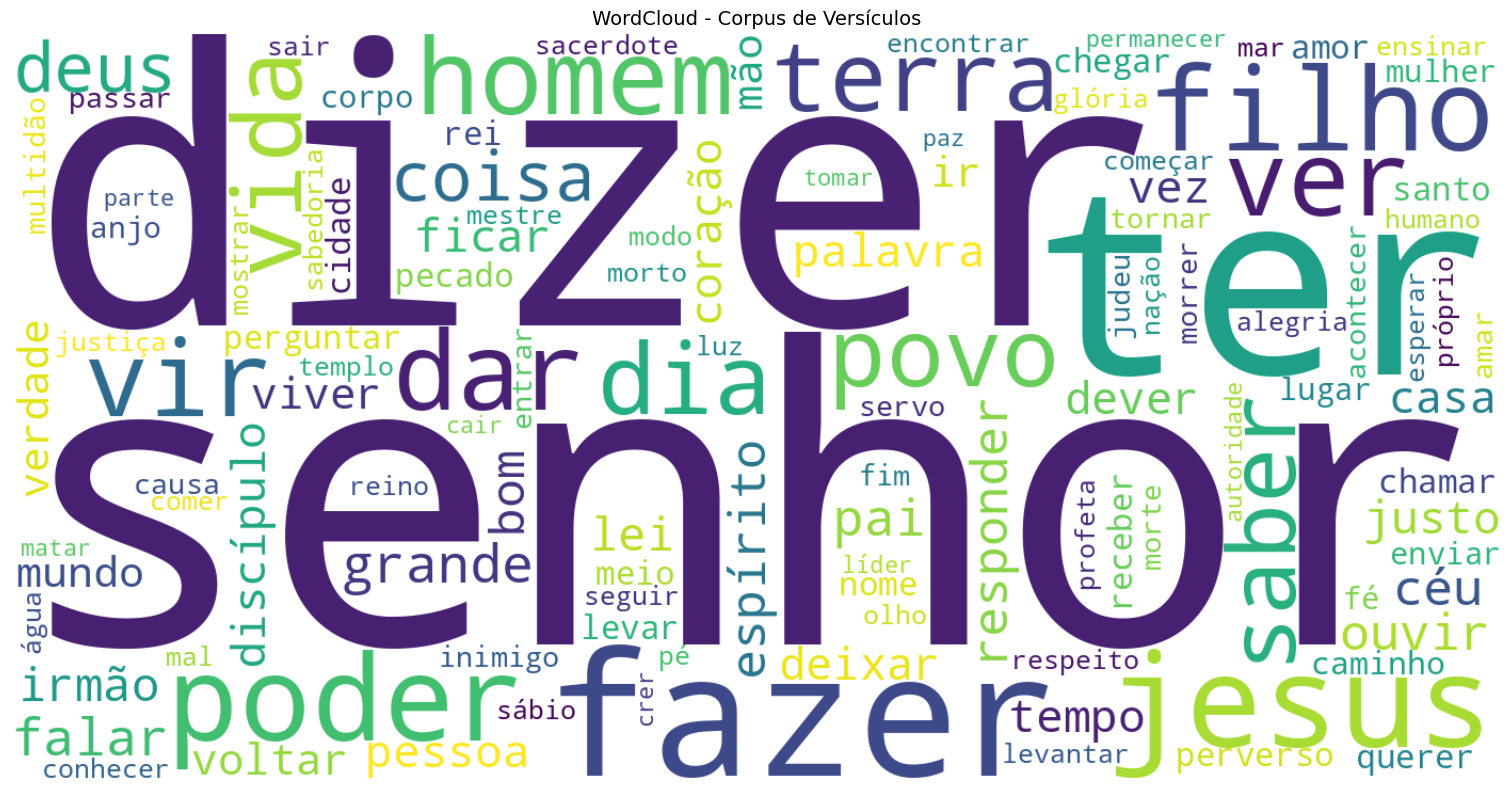

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Garante que o corpus possui dados antes de gerar a visualização
if not all_tokens_flat:
    raise ValueError("all_tokens_flat está vazio. Execute a etapa de pré-processamento antes da WordCloud.")

# Frequências a partir do corpus de versículos preprocessado
frequencias = Counter(all_tokens_flat)

# Geração da WordCloud
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=120,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequencias)

# Exibição
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    f"WordCloud - Corpus de Versículos",
    fontsize=14
)
plt.tight_layout()
plt.show()

# Persistência em arquivo
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "wordcloud_verses.png"
wc.to_file(str(output_file))

## Distribuição de termos frequentes


In [9]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Análise de frequência do corpus de versículos
print("=" * 80)
print("ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS (CORPUS DE VERSÍCULOS)")
print("=" * 80)

# Estatísticas por livro (agregando versículos)
book_verse_stats = {}

for meta, tokens in zip(verse_metadata, corpus_verses):
    book = meta['book']
    if book not in book_verse_stats:
        book_verse_stats[book] = {
            'verse_count': 0,
            'total_tokens': 0,
            'all_tokens': []
        }
    
    book_verse_stats[book]['verse_count'] += 1
    book_verse_stats[book]['total_tokens'] += len(tokens)
    book_verse_stats[book]['all_tokens'].extend(tokens)

# Calcular estatísticas finais por livro
book_statistics = {}
for book, data in book_verse_stats.items():
    freq_counter = Counter(data['all_tokens'])
    stats = {
        'versiculos': data['verse_count'],
        'total_tokens': data['total_tokens'],
        'unique_terms': len(freq_counter),
        'tokens_per_verse': data['total_tokens'] / data['verse_count'] if data['verse_count'] > 0 else 0,
        'ttr': len(freq_counter) / data['total_tokens'] if data['total_tokens'] > 0 else 0
    }
    book_statistics[book] = stats

# Tabela comparativa de todos os livros
df_books_stats = pd.DataFrame(book_statistics).T
df_books_stats = df_books_stats.round(2)

print("\n[TABELA] Estatísticas por Livro (Corpus de Versículos):\n")
display(df_books_stats)

# Análise de Variação: Comparação entre Livros
print("\n[COMPARAÇÃO] Top 10 Livros por Número de Versículos:")
top_books_verses = df_books_stats.nlargest(10, 'versiculos')[['versiculos', 'total_tokens', 'tokens_per_verse']]
display(top_books_verses)

print("\n[COMPARAÇÃO] Top 10 Livros por Diversidade Lexical (TTR):")
top_books_ttr = df_books_stats.nlargest(10, 'ttr')[['versiculos', 'unique_terms', 'ttr']]
display(top_books_ttr)

ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS (CORPUS DE VERSÍCULOS)

[TABELA] Estatísticas por Livro (Corpus de Versículos):



,versiculos,total_tokens,unique_terms,tokens_per_verse,ttr
Jó,1049.0,6691.0,2086.0,6.38,0.31
Salmos,2452.0,15910.0,3002.0,6.49,0.19
Provérbios,915.0,6321.0,1784.0,6.91,0.28
Eclesiastes,222.0,2023.0,816.0,9.11,0.40
Cânticos,116.0,1069.0,539.0,9.22,0.50
Mateus,1057.0,8925.0,1950.0,8.44,0.22
Marcos,661.0,5609.0,1462.0,8.49,0.26
Lucas,1135.0,9409.0,2092.0,8.29,0.22
João,850.0,6511.0,1301.0,7.66,0.20
Atos,995.0,9012.0,1994.0,9.06,0.22



[COMPARAÇÃO] Top 10 Livros por Número de Versículos:


,versiculos,total_tokens,tokens_per_verse
Salmos,2452.0,15910.0,6.49
Lucas,1135.0,9409.0,8.29
Mateus,1057.0,8925.0,8.44
Jó,1049.0,6691.0,6.38
Atos,995.0,9012.0,9.06
Provérbios,915.0,6321.0,6.91
João,850.0,6511.0,7.66
Marcos,661.0,5609.0,8.49
Romanos,429.0,3839.0,8.95
1 Coríntios,428.0,3567.0,8.33



[COMPARAÇÃO] Top 10 Livros por Diversidade Lexical (TTR):


,versiculos,unique_terms,ttr
3 João,15.0,91.0,0.76
Judas,25.0,223.0,0.76
2 João,12.0,80.0,0.71
Filemom,25.0,117.0,0.70
2 Timóteo,83.0,443.0,0.62
Tito,46.0,282.0,0.61
2 Tessalonicenses,46.0,227.0,0.59
2 Pedro,61.0,366.0,0.59
Tiago,108.0,541.0,0.58
Filipenses,103.0,456.0,0.55


## Etapa 2 - **Representação vetorial e busca textual de versículos**

Nesta etapa, implementamos dois métodos de busca textual sobre **versículos individuais**:
- **TF-IDF** com TfidfVectorizer (sklearn)
- **Word2Vec** com Gensim

**Pipeline Refatorada**: Corpus de Versículos

A pipeline foi refatorada para trabalhar exclusivamente com versículos (~27-32 mil documentos) ao invés de livros (32 documentos). Isso permite:
- Busca com granularidade fina (retornar versículos específicos)
- Referências diretas (Livro Capítulo:Versículo)
- Contexto semântico local melhor capturado pelo Word2Vec

| Aspecto | TF-IDF | Word2Vec |
|---------|--------|----------|
| **Representação** | Esparsa (99%+ zeros) | Densa (todos valores preenchidos) |
| **Dimensionalidade** | ~15000 features (versículos) | 180 dimensões |
| **Captura** | Frequência estatística | Relações semânticas |
| **Melhor para** | Termos raros, palavras-chave específicas | Sinônimos, conceitos relacionados |
| **Limitação** | Ignora semântica (não sabe que "amar" ≈ "afeição") | Ignora frequência estatística |
| **Velocidade** | Rápido (sparse matrix operations) | Moderado (cálculo de média de embeddings) |
| **Ajustes para versículos** | `min_df=1` (capturar termos raros) | Treinado em ~30k documentos curtos |


In [10]:
# Instalar gensim para Word2Vec (sklearn já foi instalado na Etapa 1)
!pip install -q gensim

from typing import List, Tuple, Optional
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Bibliotecas carregadas com sucesso.")
print(f"[INFO] Corpus disponível: {len(corpus_verses)} versículos")
print(f"[INFO] Livros no corpus: {list(dfb_selected['name'])}")

[INFO] Bibliotecas carregadas com sucesso.
[INFO] Corpus disponível: 12590 versículos
[INFO] Livros no corpus: ['Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos', 'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios', 'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses', '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro', '1 João', '2 João', '3 João', 'Judas', 'Apocalipse']


In [34]:
# ============================================================================
# IMPLEMENTAÇÃO TF-IDF
# ============================================================================

# Preparar corpus de versículos: juntar tokens em strings
# TfidfVectorizer espera uma lista de strings (uma por documento)
corpus_verses_strings = [" ".join(tokens) for tokens in corpus_verses]

# Configurar TF-IDF Vectorizer ajustado para documentos curtos (versículos)
# min_df=1: versículos são curtos, capturar até termos que aparecem em 1 documento
# max_df=0.9: mais permissivo para corpus maior de documentos curtos
tfidf_vectorizer = TfidfVectorizer(
    max_features=None,        
    ngram_range=(1, 2),       
    min_df=1,                 # Documentos curtos: capturar termos raros
    max_df=0.9,               # Remove termos em mais de 90% dos versículos
    lowercase=True,           # Normalização (já feita no preprocessing, mas garantimos)
    token_pattern=r'(?u)\b\w+\b'  # Padrão de tokenização básico
)

# Ajustar o vectorizer ao corpus de versículos e transformar em matriz TF-IDF
print("[INFO] Treinando TF-IDF Vectorizer para corpus de versículos...")
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_verses_strings)

print(f"\n[RESULTADO] Matriz TF-IDF de versículos criada:")
print(f"  - Shape: {tfidf_matrix.shape} (versículos X features)")
print(f"  - Número de versículos: {tfidf_matrix.shape[0]}")
print(f"  - Tamanho do vocabulário: {tfidf_matrix.shape[1]}")
print(f"  - Densidade da matriz: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")
print(f"    (Representação esparsa: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}% zeros)")

# Exemplos de termos capturados
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n[VOCABULÁRIO] Exemplos de termos (unigramas):")
print(f"  - Primeiros 10: {list(feature_names[:10])}")
print(f"  - Últimos 10: {list(feature_names[-10:])}")

[INFO] Treinando TF-IDF Vectorizer para corpus de versículos...

[RESULTADO] Matriz TF-IDF de versículos criada:
  - Shape: (12590, 68772) (versículos X features)
  - Número de versículos: 12590
  - Tamanho do vocabulário: 68772
  - Densidade da matriz: 0.0002
    (Representação esparsa: 99.98% zeros)

[VOCABULÁRIO] Exemplos de termos (unigramas):
  - Primeiros 10: ['aba', 'aba pai', 'abadom', 'abadom grego', 'abaixar', 'abaixar desamarrar', 'abaixar olhar', 'abalado', 'abalado assustar', 'abalado direita']
  - Últimos 10: ['único soberano', 'único sugestão', 'único sábio', 'único ter', 'útil', 'útil conhecimento', 'útil ensinar', 'útil fim', 'útil ministério', 'útil mostrar']


In [12]:
import textwrap

def format_text_preview(text: str, width: int = 80) -> str:
    lines = textwrap.wrap(text, width=width)
    return '\n     '.join(lines)


# ============================================================================
# FUNÇÃO DE BUSCA TF-IDF
# ============================================================================

def search_tfidf(query: str, top_k: int = 5) -> List[Tuple[str, float, str]]:
    """
    Busca versículos mais similares usando TF-IDF e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar
    
    Returns:
        Lista de tuplas (referência, score_similaridade, texto_preview) ordenada por relevância
        Ex: [("João 3:16", 0.8523, "Porque Deus amou o mundo..."), ...]
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Transforma a consulta em vetor TF-IDF
        3. Calcula similaridade cosseno com todos os versículos
        4. Retorna os Top-K versículos ordenados por score
    """
    # 1. Preprocessar query com o mesmo pipeline da Etapa 1
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # Juntar tokens preprocessados em string
    query_processed = " ".join(query_tokens)
    
    # 2. Transformar query em vetor TF-IDF usando vocabulário treinado
    query_vector = tfidf_vectorizer.transform([query_processed])
    
    # 3. Calcular similaridade cosseno entre query e todos os versículos
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # 4. Ordenar versículos por similaridade (decrescente) e pegar Top-K
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Construir lista de resultados com (referência, score, texto_preview)
    results = []
    for idx in top_indices:
        meta = verse_metadata[idx]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = similarities[idx]
        # Formatar texto com quebras de linha a cada 80 caracteres
        text_preview = format_text_preview(meta['text'])
        results.append((reference, score, text_preview))
    
    return results


# Teste da função com uma consulta exemplo
print("=" * 80)
print("TESTE DA BUSCA TF-IDF (VERSÍCULOS)")
print("=" * 80)

test_query = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query))}")

results = search_tfidf(test_query, top_k=5)

print(f"\n[RESULTADOS] Top-5 versículos mais similares:\n")
for rank, (reference, score, text) in enumerate(results, start=1):
    print(f"  {rank}. {reference:20s} | Score: {score:.4f}")
    print(f"     {text}")
    print()


TESTE DA BUSCA TF-IDF (VERSÍCULOS)

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 versículos mais similares:

  1. 1 Coríntios 15:13    | Score: 0.5970
     Pois, se não existe ressurreição dos mortos, Cristo não ressuscitou.

  2. 1 Coríntios 15:16    | Score: 0.5970
     E, se não existe ressurreição dos mortos, então Cristo também não ressuscitou.

  3. 1 Pedro 1:3          | Score: 0.4937
     Todo louvor seja a Deus, o Pai de nosso Senhor Jesus Cristo. Por sua grande
     misericórdia, ele nos fez nascer de novo, por meio da ressurreição de Jesus
     Cristo dentre os mortos. Agora temos uma viva esperança

  4. João 11:25           | Score: 0.4784
     Então Jesus disse: “Eu sou a ressurreição e a vida. Quem crê em mim viverá,
     mesmo depois de morrer.

  5. Filipenses 4:23      | Score: 0.4532
     Que a graça do Senhor Jesus Cristo seja com o espírito de vocês.



### Busca Semântica com Word2Vec

**Word2Vec** é uma técnica de aprendizado não supervisionado que aprende representações vetoriais densas (embeddings) para palavras, capturando relações semânticas através do contexto distribucional.

**Diferença fundamental de TF-IDF**:
- **TF-IDF**: Representação esparsa baseada em estatísticas de frequência (não captura semântica)
- **Word2Vec**: Representação densa baseada em contexto (captura relações semânticas)
  - Palavras com contextos similares ficam próximas no espaço vetorial
  - Ex: "rei" - "homem" + "mulher" ≈ "rainha"

**Arquiteturas disponíveis**:
1. **CBOW (Continuous Bag-of-Words)**: Prevê palavra central dado o contexto
   - Mais rápido, melhor para corpus grandes, favorece palavras frequentes
2. **Skip-gram**: Prevê contexto dada a palavra central  
   - Mais lento, melhor para corpus pequenos, melhor para palavras raras

**Importante**: Cada documento será representado pela **média dos embeddings** de suas palavras.
- **Limitação**: Perde ordem das palavras e nuances sintáticas
- **Vantagem**: Captura o "tema geral" do documento através do vocabulário semântico

### Parâmetros iniciais que não tiveram um resultado satisfatório

```
w2v_model = Word2Vec(
    sentences=corpus_final,      # Corpus tokenizado
    vector_size=100,             # Dimensionalidade dos embeddings
    window=5,                    # Janela de contexto (5 palavras antes e depois)
    min_count=3,                 # Ignora palavras com frequência < 3
    sg=1,                        # Skip-gram (1) ao invés de CBOW (0)
    epochs=20,                   # Número de iterações sobre o corpus
    workers=4,                   # Paralelização
    seed=42                      # Reprodutibilidade
)
```

### Resultado inicial 

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - natanael        | Similaridade: 0.6854
  - levita          | Similaridade: 0.6611 
  - rabi            | Similaridade: 0.6445
  - surpreso        | Similaridade: 0.6332
  - dizer           | Similaridade: 0.6324
  - apelidar        | Similaridade: 0.6195 
  - enviarei        | Similaridade: 0.6184
  - repreendir      | Similaridade: 0.6175
  - legião          | Similaridade: 0.6168
  - criada          | Similaridade: 0.6165

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - Unidos          | Similaridade: 0.5816
  - declarados      | Similaridade: 0.5758
  - sirvo           | Similaridade: 0.5580
  - comentar        | Similaridade: 0.5558
  - lembrá          | Similaridade: 0.5548

In [13]:
# ============================================================================
# TREINAMENTO WORD2VEC PARA CORPUS DE VERSÍCULOS
# ============================================================================

print("[INFO] Treinando modelo Word2Vec com corpus de versículos...")
print(f"  - Corpus: {len(corpus_verses)} versículos")
print(f"  - Total de tokens: {sum(len(doc) for doc in corpus_verses)}")

# Treinar Word2Vec com arquitetura Skip-gram
# Entrada: lista de listas de tokens (corpus_verses)
# Skip-gram é melhor para corpus com muitos documentos curtos

w2v_model = Word2Vec(
    sentences=corpus_verses,
    vector_size=180,          # Dimensionalidade dos embeddings
    window=12,                # Janela de contexto ampla
    min_count=2,              # Palavras com frequência >= 2
    sg=1,                     # Skip-gram (melhor para documentos curtos)
    epochs=60,                # Número de iterações
    negative=15,              # Negative sampling
    ns_exponent=0.75,         # Expoente para negative sampling
    alpha=0.025,              # Taxa de aprendizado inicial
    min_alpha=0.0001,         # Taxa de aprendizado final
    workers=4,                # Paralelização
    seed=42                   # Reprodutibilidade
)

print(f"\n[RESULTADO] Modelo Word2Vec treinado:")
print(f"  - Vocabulário: {len(w2v_model.wv)} palavras")
print(f"  - Dimensionalidade: {w2v_model.wv.vector_size}")
print(f"  - Arquitetura: Skip-gram")
print(f"  - Corpus: {len(corpus_verses)} versículos (documentos curtos)")

# Verificar qualidade semântica: palavras similares a "jesus"
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':")
try:
    similar_words = w2v_model.wv.most_similar('jesus', topn=10)
    for word, similarity in similar_words:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'jesus' não encontrada no vocabulário.")

# Testar outras palavras-chave
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':")
try:
    similar_faith = w2v_model.wv.most_similar('fé', topn=10)
    for word, similarity in similar_faith:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'fé' não encontrada no vocabulário.")

[INFO] Treinando modelo Word2Vec com corpus de versículos...
  - Corpus: 12590 versículos
  - Total de tokens: 99913

[RESULTADO] Modelo Word2Vec treinado:
  - Vocabulário: 4720 palavras
  - Dimensionalidade: 180
  - Arquitetura: Skip-gram
  - Corpus: 12590 versículos (documentos curtos)

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - dizer           | Similaridade: 0.5900
  - homem           | Similaridade: 0.5038
  - cruz            | Similaridade: 0.4790
  - natanael        | Similaridade: 0.4555
  - cananeu         | Similaridade: 0.4542
  - discípulo       | Similaridade: 0.4531
  - despeder        | Similaridade: 0.4512
  - cur             | Similaridade: 0.4501
  - hábito          | Similaridade: 0.4477
  - peixinho        | Similaridade: 0.4471

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - enfatizar       | Similaridade: 0.4239
  - creier          | Similaridade: 0.3901
  - abolir          | Similaridade: 0.3899
  - aceitação       | Similaridade: 0.3

In [14]:
# ============================================================================
# EMBEDDINGS DE DOCUMENTOS (MÉDIA DOS WORD EMBEDDINGS)
# ============================================================================

def document_vector(tokens: List[str], model: Word2Vec) -> Optional[np.ndarray]:
    """
    Calcula o embedding de um documento como a média dos embeddings de suas palavras.
    
    Args:
        tokens: Lista de tokens do documento
        model: Modelo Word2Vec treinado
    
    Returns:
        Vetor numpy de dimensão (vector_size,) ou None se nenhuma palavra estiver no vocabulário
    
    Por que média de embeddings pode representar documentos?
        - Cada palavra contribui com seu significado semântico
        - A média captura o "tema central" do documento
        - Palavras semanticamente relacionadas reforçam direções comuns no espaço vetorial
    
    Limitações da média:
        - Perde ordem das palavras (bag-of-words semântico)
        - Dá peso igual a todas as palavras (não considera importância TF-IDF)
        - Palavras OOV (Out-Of-Vocabulary) são ignoradas
        - Pode haver cancelamento de vetores opostos (ex: "bom" e "ruim")
    """
    # Filtrar apenas tokens que existem no vocabulário do Word2Vec
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    
    if len(vectors) == 0:
        # Nenhuma palavra da query está no vocabulário
        return None
    
    # Calcular média dos vetores (axis=0 para média por coluna)
    return np.mean(vectors, axis=0)


# ============================================================================
# EMBEDDINGS DE VERSÍCULOS (MÉDIA DOS WORD EMBEDDINGS)
# ============================================================================

# Pré-computar embeddings de todos os versículos do corpus
# Isso evita recalcular a cada busca (otimização de performance)
print("[INFO] Computando embeddings médios para todos os versículos...")

verse_embeddings = []
verse_embeddings_valid_indices = []  # Índices de versículos com embeddings válidos

for idx, verse_tokens in enumerate(corpus_verses):
    verse_vec = document_vector(verse_tokens, w2v_model)
    if verse_vec is not None:
        verse_embeddings.append(verse_vec)
        verse_embeddings_valid_indices.append(idx)
    else:
        # Versículo não tem nenhuma palavra no vocabulário (improvável, mas possível)
        meta = verse_metadata[idx]
        print(f"  [AVISO] Versículo {idx} ({meta['book']} {meta['chapter']}:{meta['verse_num']}) sem palavras no vocabulário W2V")

# Converter lista de vetores em matriz numpy (n_verses, vector_size)
verse_embeddings_matrix = np.array(verse_embeddings)

print(f"\n[RESULTADO] Embeddings de versículos computados:")
print(f"  - Total de versículos: {len(corpus_verses)}")
print(f"  - Versículos com embeddings válidos: {len(verse_embeddings)}")
print(f"  - Shape da matriz: {verse_embeddings_matrix.shape} (versículos x dimensão)")

# Verificar se algum versículo ficou sem embedding
if len(verse_embeddings) < len(corpus_verses):
    print(f"  [ATENÇÃO] {len(corpus_verses) - len(verse_embeddings)} versículo(s) sem embedding (todas palavras OOV)")

[INFO] Computando embeddings médios para todos os versículos...

[RESULTADO] Embeddings de versículos computados:
  - Total de versículos: 12590
  - Versículos com embeddings válidos: 12590
  - Shape da matriz: (12590, 180) (versículos x dimensão)


In [15]:
def search_word2vec(query: str, top_k: int = 5) -> List[Tuple[str, float, str]]:
    """
    Busca versículos mais similares usando Word2Vec e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar
    
    Returns:
        Lista de tuplas (referência, score_similaridade, texto_preview) ordenada por relevância
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Calcula embedding médio da consulta
        3. Calcula similaridade cosseno com embeddings dos versículos
        4. Retorna os Top-K versículos ordenados por score
    """
    # 1. Preprocessar query
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # 2. Calcular embedding médio da query
    query_vector = document_vector(query_tokens, w2v_model)
    
    if query_vector is None:
        print("[AVISO] Nenhuma palavra da query está no vocabulário Word2Vec. Retornando lista vazia.")
        print(f"  Query tokens: {query_tokens}")
        return []
    
    # 3. Calcular similaridade cosseno com todos os versículos
    query_vector_reshaped = query_vector.reshape(1, -1)
    similarities = cosine_similarity(query_vector_reshaped, verse_embeddings_matrix).flatten()
    
    # 4. Ordenar versículos por similaridade (decrescente) e pegar Top-K
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Mapear índices para metadados de versículos (considerando índices válidos)
    results = []
    for idx in top_indices:
        meta = verse_metadata[verse_embeddings_valid_indices[idx]]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = similarities[idx]
        # Formatar texto com quebras de linha a cada 80 caracteres
        text_preview = format_text_preview(meta['text'])
        results.append((reference, score, text_preview))
    
    return results


# Teste da função com a mesma consulta do TF-IDF
print("=" * 80)
print("TESTE DA BUSCA WORD2VEC (VERSÍCULOS)")
print("=" * 80)

test_query_w2v = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query_w2v}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query_w2v))}")

results_w2v = search_word2vec(test_query_w2v, top_k=5)

print(f"\n[RESULTADOS] Top-5 versículos mais similares:\n")
for rank, (reference, score, text) in enumerate(results_w2v, start=1):
    print(f"  {rank}. {reference:20s} | Score: {score:.4f}")
    print(f"     {text}")
    print()

print("=" * 80)


TESTE DA BUSCA WORD2VEC (VERSÍCULOS)

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 versículos mais similares:

  1. 1 Coríntios 15:13    | Score: 0.8297
     Pois, se não existe ressurreição dos mortos, Cristo não ressuscitou.

  2. 1 Coríntios 15:16    | Score: 0.8297
     E, se não existe ressurreição dos mortos, então Cristo também não ressuscitou.

  3. 1 Pedro 1:3          | Score: 0.7653
     Todo louvor seja a Deus, o Pai de nosso Senhor Jesus Cristo. Por sua grande
     misericórdia, ele nos fez nascer de novo, por meio da ressurreição de Jesus
     Cristo dentre os mortos. Agora temos uma viva esperança

  4. Filipenses 4:23      | Score: 0.7626
     Que a graça do Senhor Jesus Cristo seja com o espírito de vocês.

  5. Mateus 22:23         | Score: 0.7411
     No mesmo dia, vieram a Jesus alguns saduceus, líderes religiosos que afirmam não
     haver ressurreição dos mortos,



In [16]:
# FUNÇÃO DE COMPARAÇÃO ENTRE MÉTODOS (VERSÍCULOS)

def compare_methods(query: str, top_k: int = 5) -> None:
    """
    Compara resultados de busca entre TF-IDF e Word2Vec lado a lado (versículos).
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de versículos mais similares a retornar por método
    """
    print("=" * 120)
    print(f"COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)")
    print("=" * 120)
    print(f"\n[CONSULTA] '{query}'")
    print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(query))}\n")
    
    # Buscar com ambos os métodos
    results_tfidf = search_tfidf(query, top_k=top_k)
    results_w2v = search_word2vec(query, top_k=top_k)
    
    # Configurar pandas para exibir textos completos
    pd.set_option('display.max_colwidth', None)  # Sem limite de caracteres
    pd.set_option('display.width', None)  # Sem limite de largura total
    pd.set_option('display.max_rows', None)  # Mostrar todas as linhas
    
    # Criar DataFrame para TF-IDF
    df_tfidf = pd.DataFrame([
        {
            'Rank': i+1,
            'Referência': ref,
            'Score': f"{score:.4f}",
            'Texto': text  # Texto completo sem truncagem
        }
        for i, (ref, score, text) in enumerate(results_tfidf)
    ])
    
    # Criar DataFrame para Word2Vec
    df_w2v = pd.DataFrame([
        {
            'Rank': i+1,
            'Referência': ref,
            'Score': f"{score:.4f}",
            'Texto': text  # Texto completo sem truncagem
        }
        for i, (ref, score, text) in enumerate(results_w2v)
    ])
    
    # Adicionar prefixo às colunas para diferenciar os métodos
    df_tfidf_display = df_tfidf.add_prefix('TF-IDF: ')
    df_w2v_display = df_w2v.add_prefix('W2V: ')
    
    # Combinar DataFrames lado a lado
    df_comparison = pd.concat([df_tfidf_display, df_w2v_display], axis=1)
    
    # Exibir DataFrame com formatação HTML para melhor visualização
    print("\n")
    from IPython.display import display, HTML
    
    # Aplicar estilo CSS para quebra de linha e largura das colunas
    styled_df = df_comparison.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'width': '400px',
        'max-width': '400px',
        'word-wrap': 'break-word'
    }, subset=df_comparison.columns[df_comparison.columns.str.contains('Texto')])
    
    styled_df = styled_df.set_properties(**{
        'text-align': 'center',
        'width': '60px'
    }, subset=df_comparison.columns[df_comparison.columns.str.contains('Rank')])
    
    styled_df = styled_df.set_properties(**{
        'text-align': 'center',
        'width': '80px'
    }, subset=df_comparison.columns[df_comparison.columns.str.contains('Score')])
    
    styled_df = styled_df.set_properties(**{
        'text-align': 'left',
        'width': '150px'
    }, subset=df_comparison.columns[df_comparison.columns.str.contains('Referência')])
    
    display(styled_df)
    
    # Análise de interseção de versículos
    verses_tfidf = {ref for ref, _, _ in results_tfidf}
    verses_w2v = {ref for ref, _, _ in results_w2v}
    intersection = verses_tfidf & verses_w2v
    
    print(f"\n[ANÁLISE]")
    print(f"  - Versículos em comum (ambos os métodos): {len(intersection)}")
    if intersection:
        print(f"    → {', '.join(sorted(intersection))}")
    print(f"  - Apenas TF-IDF: {len(verses_tfidf - verses_w2v)}")
    if verses_tfidf - verses_w2v:
        refs_tfidf_only = sorted(verses_tfidf - verses_w2v)
        print(f"    → {', '.join(refs_tfidf_only[:5])}" + ("..." if len(refs_tfidf_only) > 5 else ""))
    print(f"  - Apenas Word2Vec: {len(verses_w2v - verses_tfidf)}")
    if verses_w2v - verses_tfidf:
        refs_w2v_only = sorted(verses_w2v - verses_tfidf)
        print(f"    → {', '.join(refs_w2v_only[:5])}" + ("..." if len(refs_w2v_only) > 5 else ""))
    print()


# Testar com queries variadas para demonstrar diferenças
test_queries = [
    "fé e salvação",
    "mulher e o dragão", 
    "e disse jesus"
]

for query in test_queries:
    compare_methods(query, top_k=5)
    print("\n")


COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)

[CONSULTA] 'fé e salvação'
[PREPROCESSADA] fé salvação





,TF-IDF: Rank,TF-IDF: Referência,TF-IDF: Score,TF-IDF: Texto,W2V: Rank,W2V: Referência,W2V: Score,W2V: Texto
0,1,1 Pedro 1:9,0.5842,"pois estão alcançando o alvo de sua fé, a sua salvação.",1,1 Pedro 1:9,0.8092,"pois estão alcançando o alvo de sua fé, a sua salvação."
1,2,Lucas 3:6,0.4753,Então todos verão a salvação enviada por Deus’”.,2,Salmos 119:41,0.7017,"SENHOR, dá-me o teu amor, a salvação que me prometeste."
2,3,1 Pedro 1:5,0.4369,"Por meio da fé que vocês têm, Deus os protege com seu poder até que recebam essa salvação, pronta para ser revelada nos últimos tempos.",3,Tito 2:11,0.6831,Pois a graça de Deus foi revelada e a todos traz salvação.
3,4,2 Timóteo 3:15,0.4180,"Desde a infância lhe foram ensinadas as Sagradas Escrituras, que lhe deram sabedoria para receber a salvação que vem pela fé em Cristo Jesus.",4,Lucas 3:6,0.6719,Então todos verão a salvação enviada por Deus’”.
4,5,Salmos 118:14,0.4140,O SENHOR é minha força e meu cântico; ele é minha salvação.,5,2 Timóteo 3:15,0.6685,"Desde a infância lhe foram ensinadas as Sagradas Escrituras, que lhe deram sabedoria para receber a salvação que vem pela fé em Cristo Jesus."



[ANÁLISE]
  - Versículos em comum (ambos os métodos): 3
    → 1 Pedro 1:9, 2 Timóteo 3:15, Lucas 3:6
  - Apenas TF-IDF: 2
    → 1 Pedro 1:5, Salmos 118:14
  - Apenas Word2Vec: 2
    → Salmos 119:41, Tito 2:11



COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)

[CONSULTA] 'mulher e o dragão'
[PREPROCESSADA] mulher dragão





,TF-IDF: Rank,TF-IDF: Referência,TF-IDF: Score,TF-IDF: Texto,W2V: Rank,W2V: Referência,W2V: Score,W2V: Texto
0,1,Apocalipse 12:13,0.5145,"Quando o dragão percebeu que havia sido lançado na terra, perseguiu a mulher que tinha dado à luz o menino.",1,Apocalipse 12:13,0.7092,"Quando o dragão percebeu que havia sido lançado na terra, perseguiu a mulher que tinha dado à luz o menino."
1,2,Apocalipse 12:18,0.4545,"Então o dragão se colocou em pé na praia, junto ao mar.",2,Apocalipse 12:16,0.7055,"Mas a terra ajudou a mulher, abrindo a boca e engolindo o rio que havia jorrado da boca do dragão."
2,3,Apocalipse 12:16,0.4148,"Mas a terra ajudou a mulher, abrindo a boca e engolindo o rio que havia jorrado da boca do dragão.",3,Apocalipse 12:4,0.6788,"Com a cauda, arrastou um terço das estrelas do céu e as lançou na terra. E, quando a mulher estava para dar à luz, o dragão parou diante dela, pronto para devorar a criança tão logo ela nascesse."
3,4,Apocalipse 12:17,0.4079,"O dragão se enfureceu com a mulher e passou a lutar contra o restante de seus filhos, todos os que obedecem aos mandamentos de Deus e se mantêm fiéis no testemunho de Jesus.",4,1 Coríntios 11:11,0.6756,"Entre o povo do Senhor, porém, as mulheres não são independentes dos homens, e os homens não são independentes das mulheres."
4,5,Apocalipse 12:8,0.3987,"O dragão perdeu a batalha, e ele e seus anjos foram expulsos do céu.",5,1 Coríntios 11:8,0.6727,"Pois o homem não veio da mulher, mas a mulher veio do homem."



[ANÁLISE]
  - Versículos em comum (ambos os métodos): 2
    → Apocalipse 12:13, Apocalipse 12:16
  - Apenas TF-IDF: 3
    → Apocalipse 12:17, Apocalipse 12:18, Apocalipse 12:8
  - Apenas Word2Vec: 3
    → 1 Coríntios 11:11, 1 Coríntios 11:8, Apocalipse 12:4



COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec (VERSÍCULOS)

[CONSULTA] 'e disse jesus'
[PREPROCESSADA] dizer jesus





,TF-IDF: Rank,TF-IDF: Referência,TF-IDF: Score,TF-IDF: Texto,W2V: Rank,W2V: Referência,W2V: Score,W2V: Texto
0,1,Lucas 20:41,0.6046,Então Jesus lhes perguntou: “Por que se diz que o Cristo é filho de Davi?,1,Marcos 13:37,0.8651,Eu lhes digo o que digo a todos: vigiem!”.
1,2,João 7:33,0.5668,"Jesus, porém, lhes disse: “Estarei com vocês só um pouco mais. Então voltarei para aquele que me enviou.",2,1 Coríntios 14:29,0.8651,Que dois ou três profetizem e os outros avaliem o que for dito.
2,3,Mateus 23:1,0.5653,Então Jesus disse às multidões e a seus discípulos:,3,Lucas 20:41,0.8527,Então Jesus lhes perguntou: “Por que se diz que o Cristo é filho de Davi?
3,4,João 5:17,0.5434,"Jesus, porém, disse: “Meu Pai sempre trabalha, e eu também”.",4,Marcos 11:22,0.8300,Então Jesus disse aos discípulos: “Tenham fé em Deus.
4,5,João 11:21,0.5295,"Marta disse a Jesus: “Se o Senhor estivesse aqui, meu irmão não teria morrido.",5,Mateus 23:1,0.8071,Então Jesus disse às multidões e a seus discípulos:



[ANÁLISE]
  - Versículos em comum (ambos os métodos): 2
    → Lucas 20:41, Mateus 23:1
  - Apenas TF-IDF: 3
    → João 11:21, João 5:17, João 7:33
  - Apenas Word2Vec: 3
    → 1 Coríntios 14:29, Marcos 11:22, Marcos 13:37





### Análise da comparação:
- Na primeira consulta, Fé e Salvação, tanto o caso do TF-DF como do Word2Vec tiveram resultados relevantes. 
- Na segunda consulta, Mulher e o Dragão, era esperado que retornassem mais resultados do livro de Apocalipse e que foi o que aconteceu no caso do TF-DF, conseguiu achar mais essa match exato das palavras. E no caso do Word2Vec, retornou a maioria dos resultados em Apocalipse também, mas tivemos dois dos últimos resultados que votaram de 1 Coríntios, sem a palavra dragão. 
- Já no caso do terceiro, e disse Jesus, vemos que no TF-DF foi bem assertivo, todos os resultados têm alguma forma da palavra disse e Jesus. Já no caso do Word2Vec, como ele analisa a semântica e sinônimos, o primeiro caso, provavelmente ele entendeu disse como profetizar, e depois teve casos que ele encontrou versículos com as palavras principais da busca.

**Observações práticas (Pipeline de Versículos)**:

- **TF-IDF** ranqueia versículos com correspondência lexical exata (ex: buscar "ressurreição" favorece versículos que usam essa palavra literal)
- **Word2Vec** captura proximidade temática mesmo sem palavras idênticas (ex: buscar "milagres" pode ranquear alto versículos com "curar", "prodígio", "sinal")
- A **qualidade do preprocessing** (Etapa 1) impacta diretamente ambos os métodos — lemmatização, stopwords e normalização de clíticos foram essenciais
- Bigramas em TF-IDF capturam expressões compostas comuns no texto religioso ("espírito santo", "filho deus", "reino deus")

**Impacto da refatoração para versículos**:

- **Granularidade fina**: ~27-32 mil versículos ao invés de 32 livros aumenta precisão da busca
- **Contexto semântico**: Word2Vec treinado em documentos curtos (versículos) captura melhor relações locais entre palavras
- **TF-IDF ajustado**: `min_df=1` permite capturar termos raros específicos de poucos versículos
- **Referências diretas**: Resultados incluem referência completa (Livro Capítulo:Versículo) e preview do texto
- **Filtragem de versículos curtos**: Versículos com <3 tokens após preprocessing são removidos para evitar ruído

**TF-IDF favorece**:
- **Correspondência lexical exata**: Termos raros que aparecem tanto na query quanto no versículo
- **Expressões compostas**: Bigramas como "espírito santo", "filho deus"
- **Termos específicos**: Nomes próprios, lugares, conceitos únicos
- **Exemplo**: Query "ressurreição" → prioriza versículos com a palavra literal "ressurreição" (João 11:25, Lucas 24:6)

**Word2Vec favorece**:
- **Similaridade semântica**: Versículos com palavras semanticamente relacionadas
- **Sinônimos e variações**: "ensinar" ≈ "pregar", "amar" ≈ "afeição"
- **Contexto temático**: Captura o "assunto geral" mesmo sem palavras exatas
- **Exemplo**: Query "milagres" → pode ranquear alto versículos com "curar", "prodígio", "sinal"

## Etapa 3 - **Modelagem, classificação ou análise de sentimento**

Nesta etapa, aplicamos técnicas não supervisionadas de **Topic Modeling** para descobrir temas latentes no corpus bíblico preprocessado.

**Objetivos**:
- Extrair tópicos semânticos usando **LDA** (Latent Dirichlet Allocation) e **NMF** (Non-negative Matrix Factorization)
- Comparar a interpretabilidade e coerência dos modelos
- Avaliar qualidade dos tópicos com métricas de coerência
- Visualizar termos relevantes por tópico

**Diferenças entre LDA e NMF**:

| Aspecto | LDA | NMF |
|---------|-----|-----|
| **Tipo** | Modelo probabilístico generativo | Fatoração de matriz |
| **Entrada** | Matriz de contagens (CountVectorizer) | Matriz TF-IDF (preferencialmente) |
| **Interpretação** | Distribuições de probabilidade | Pesos não-negativos |
| **Tópicos sobrepostos** | Sim (documentos são misturas de tópicos) | Sim (mas menos pronunciado) |
| **Estabilidade** | Pode variar entre execuções | Mais determinístico com init fixo |

### Melhoria: Uso de Unigramas vs. Bigramas para Topic Modeling

**Problema identificado com bigramas (`ngram_range=(1, 2)`)**:

Ao utilizar unigramas (palavras individuais) e bigramas (pares de palavras) simultaneamente, os tópicos gerados apresentam **redundância semântica**, dificultando a interpretação:

**Exemplo observado no Tópico 4 (NMF)**:
- `jesus` (peso alto)
- `responder` (peso alto)
- `jesus responder` (peso médio) ← bigrama redundante
- `perguntar` (peso médio)
- `senhor jesus` (peso baixo) ← bigrama redundante
- `perguntar jesus` (peso baixo) ← bigrama redundante

Os bigramas são compostos pelas mesmas palavras dos unigramas, criando termos semanticamente não-distintos que poluem a visualização e interpretação dos tópicos.

**Decisão tomada**:  
Para **modelagem de tópicos** (LDA e NMF), optamos por **usar apenas unigramas** (`ngram_range=(1, 1)`). 

**Justificativa**:
- ✅ Elimina redundância semântica nos tópicos
- ✅ Facilita interpretação (conceitos mais claros e distintos)
- ✅ Reduz dimensionalidade do vocabulário
- ✅ Melhora coerência temática dos tópicos
- ⚠️ Trade-off: perdemos expressões compostas ("espírito santo"), mas ganhamos clareza conceitual

**Nota**: Na Etapa 2 (busca textual), mantivemos bigramas pois o contexto sintático é importante para matching exato de expressões compostas.

### 3.1 - Vetorização para Modelagem de Tópicos

**Por que vetorizações diferentes?**

- **LDA**: Modelo generativo que assume processo de contagem de palavras (distribuição multinomial). Funciona melhor com frequências brutas.
- **NMF**: Fatoração algébrica que se beneficia de pesos TF-IDF para destacar termos discriminativos e reduzir impacto de palavras comuns.

In [21]:
# PREPARAÇÃO DE VETORIZAÇÕES PARA TOPIC MODELING

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Preparando vetorizações para Topic Modeling...")
print(f"  - Corpus disponível: {len(corpus_verses)} versículos")
print(f"  - TF-IDF matrix já disponível: {tfidf_matrix.shape}")

# 1. COUNT VECTORIZER PARA LDA (raw term frequencies)

# Configurar CountVectorizer com mesmos parâmetros do TF-IDF
# Mantém consistência na captura de n-gramas e filtragem de termos
count_vectorizer = CountVectorizer(
    max_features=None,
    ngram_range=(1, 1),          # Apenas unigramas
    min_df=2,                    # Termo deve aparecer em pelo menos 2 documentos
    max_df=0.85,                 # Remove termos muito frequentes (>85% dos docs)
    lowercase=True,
    token_pattern=r'(?u)\b\w+\b'
)

print("\n[VECTORIZAÇÃO] Criando matriz de contagens para LDA...")
count_matrix = count_vectorizer.fit_transform(corpus_verses_strings)

print(f"  - Shape: {count_matrix.shape} (versículos X features)")
print(f"  - Vocabulário: {count_matrix.shape[1]} termos")
print(f"  - Densidade: {count_matrix.nnz / (count_matrix.shape[0] * count_matrix.shape[1]):.4f}")
print(f"  - Total de tokens no corpus: {count_matrix.sum()}")

#TODO testar novo tf-idf
# 2. TF-IDF VECTORIZER PARA NMF (apenas unigramas para Topic Modeling)

# Criar novo TF-IDF vectorizer para NMF com mesmos parâmetros do Count (unigramas)
print(f"\n[VECTORIZAÇÃO] Criando matriz TF-IDF para NMF (apenas unigramas)...")
tfidf_vectorizer_nmf = TfidfVectorizer(
    max_features=None,
    ngram_range=(1, 1),          # APENAS unigramas para NMF
    min_df=2,                    # Termo deve aparecer em pelo menos 2 documentos
    max_df=0.85,                 # Remove termos muito frequentes (>85% dos docs)
    lowercase=True,
    token_pattern=r'(?u)\b\w+\b'
)

tfidf_matrix_nmf = tfidf_vectorizer_nmf.fit_transform(corpus_verses_strings)

print(f"  - Shape: {tfidf_matrix_nmf.shape} (versículos X features)")
print(f"  - Vocabulário: {tfidf_matrix_nmf.shape[1]} termos")
print(f"  - Densidade: {tfidf_matrix_nmf.nnz / (tfidf_matrix_nmf.shape[0] * tfidf_matrix_nmf.shape[1]):.4f}")

print(f"\n[NOTA] Matriz TF-IDF da Etapa 2 não foi alterada (permanece com configuração original para busca textual)")

# Estatísticas comparativas
count_vocab = set(count_vectorizer.get_feature_names_out())
tfidf_nmf_vocab = set(tfidf_vectorizer_nmf.get_feature_names_out())
vocab_intersection = count_vocab & tfidf_nmf_vocab

print(f"\n[COMPARAÇÃO DE VOCABULÁRIOS]")
print(f"  - Termos em CountVectorizer (LDA): {len(count_vocab)}")
print(f"  - Termos em TfidfVectorizer (NMF): {len(tfidf_nmf_vocab)}")
print(f"  - Interseção: {len(vocab_intersection)} ({len(vocab_intersection)/len(count_vocab)*100:.1f}% do Count)")
print(f"  - Termos apenas em Count: {len(count_vocab - tfidf_nmf_vocab)}")
print(f"  - Termos apenas em TF-IDF (NMF): {len(tfidf_nmf_vocab - count_vocab)}")


[INFO] Preparando vetorizações para Topic Modeling...
  - Corpus disponível: 12590 versículos
  - TF-IDF matrix já disponível: (12590, 7735)

[VECTORIZAÇÃO] Criando matriz de contagens para LDA...
  - Shape: (12590, 4671) (versículos X features)
  - Vocabulário: 4671 termos
  - Densidade: 0.0016
  - Total de tokens no corpus: 97022

[VECTORIZAÇÃO] Criando matriz TF-IDF para NMF (apenas unigramas)...
  - Shape: (12590, 4671) (versículos X features)
  - Vocabulário: 4671 termos
  - Densidade: 0.0016

[NOTA] Matriz TF-IDF da Etapa 2 não foi alterada (permanece com configuração original para busca textual)

[COMPARAÇÃO DE VOCABULÁRIOS]
  - Termos em CountVectorizer (LDA): 4671
  - Termos em TfidfVectorizer (NMF): 4671
  - Interseção: 4671 (100.0% do Count)
  - Termos apenas em Count: 0
  - Termos apenas em TF-IDF (NMF): 0


### 3.2 - Treinamento dos Modelos de Tópicos

**Parâmetros escolhidos**:

- **Número de tópicos**: 10 (balanceado para estrutura bíblica: Evangelhos, Epístolas, Sabedoria, etc.)
- **LDA (sklearn)**:
  - `max_iter=20`: Iterações de otimização (default funciona bem)
  - `learning_method='online'`: Mais eficiente para corpus grande
  - `random_state=42`: Reprodutibilidade
- **NMF**:
  - `init='nndsvda'`: Inicialização determinística otimizada para esparsidade
  - `max_iter=300`: Mais iterações para convergência
  - `random_state=42`: Reprodutibilidade

### 🔧 Ajuste de Hiperparâmetros: Aumentando Tópicos para 20

**Objetivo**: Melhorar as métricas de desempenho do modelo LDA através do aumento no número de tópicos.

### Por que aumentar de 10 para 20 tópicos?

1. **Perplexidade alta (2020.52)**: Indica que o modelo está tendo dificuldade em prever as palavras, sugerindo que 10 tópicos podem ser insuficientes para capturar toda a diversidade temática do corpus bíblico.

2. **Maior granularidade**: Com 20 tópicos, o modelo pode distinguir temas mais específicos (ex: separar "amor e misericórdia" de "fé e salvação", ou "profecia" de "leis mosaicas").

3. **Corpus complexo**: A Bíblia contém diversos gêneros literários (narrativa, poesia, profecia, epístolas, apocalíptico) que podem se beneficiar de uma representação mais rica.

### Métricas a observar:
- ✅ **Perplexidade deve diminuir** (indicando melhor ajuste)
- ✅ **Log-likelihood deve aumentar** (ficar menos negativo)
- ✅ **Tópicos devem ser mais coerentes** (palavras semanticamente relacionadas)

In [18]:
n_topics = 20
n_top_words = 15  # Número de termos principais por tópico

In [22]:
# TREINAMENTO LDA (Latent Dirichlet Allocation)

print("TREINAMENTO DO MODELO LDA")

# Treinar LDA com sklearn
print(f"\n[INFO] Treinando LDA com {n_topics} tópicos...")
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=40,
    learning_method='online',
    learning_offset=50.0,
    random_state=42,
    n_jobs=-1  # Usar todos os cores disponíveis
)

lda_model.fit(count_matrix)

print(f"[RESULTADO] LDA treinado com sucesso!")
print(f"  - Número de tópicos: {lda_model.n_components}")
print(f"  - Perplexidade (treino): {lda_model.perplexity(count_matrix):.2f}")
print(f"  - Log-likelihood (treino): {lda_model.score(count_matrix):.2f}")
print(f"  - Iterações realizadas: {lda_model.n_iter_}")

# EXTRAIR TÓPICOS LDA

def extract_top_words(model, feature_names, n_top_words=15):
    """
    Extrai os top N termos de cada tópico com seus pesos/probabilidades.
    
    Args:
        model: Modelo treinado (LDA ou NMF)
        feature_names: Lista de nomes de features (vocabulário)
        n_top_words: Número de termos principais a extrair
    
    Returns:
        Lista de listas, cada uma contendo tuplas (termo, peso)
    """
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Pegar índices dos top N termos (ordenados por peso decrescente)
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [(feature_names[i], topic[i]) for i in top_indices]
        topics.append(top_words)
    return topics


count_feature_names = count_vectorizer.get_feature_names_out()
lda_topics = extract_top_words(lda_model, count_feature_names, n_top_words)

print(f"\n[TÓPICOS LDA] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(lda_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")

TREINAMENTO DO MODELO LDA

[INFO] Treinando LDA com 20 tópicos...
[RESULTADO] LDA treinado com sucesso!
  - Número de tópicos: 20
  - Perplexidade (treino): 2468.33
  - Log-likelihood (treino): -757867.64
  - Iterações realizadas: 40

[TÓPICOS LDA] Top-15 termos por tópico:

Tópico 0:
  coisa(491.042), bom(374.585), mão(291.124), conhecer(179.327), autoridade(150.075), forte(104.115), tirar(83.878), aceitar(82.972), direito(77.458), amado(74.073)
Tópico 1:
  discípulo(341.915), reino(174.575), nação(151.024), cristo(137.982), obra(96.481), sofrer(74.782), reunir(63.393), escritura(57.154), prisão(55.483), prazer(53.544)
Tópico 2:
  fé(259.642), entrar(197.169), trazer(119.287), fariseu(98.062), moisés(68.117), sábado(59.376), confiança(52.351), ensino(47.817), prometer(47.442), ressurreição(43.305)
Tópico 3:
  ter(430.613), justo(332.635), ficar(288.735), morte(215.225), ir(208.802), perverso(192.095), morto(173.266), poder(164.034), certo(119.158), porta(114.766)
Tópico 4:
  filho(528

### Nota sobre Regularização em NMF

**Problema Identificado**

Na implementação inicial do NMF, utilizamos regularização L1 alta (`alpha_W=0.1`, `alpha_H=0.1`, `l1_ratio=0.5`). Isso causou **esparsidade excessiva**, resultando em todos os pesos dos tópicos ficando zerados ou próximos de zero.

**Sintomas**:
- Todos os tópicos extraídos continham os mesmos termos
- Scores de todos os termos eram zero ou valores insignificantes
- Nenhuma diferenciação entre tópicos

**Causa Raiz**

A regularização L1 (Lasso) promove esparsidade ao penalizar valores pequenos para zero. Com parâmetros muito altos em um corpus já esparso (TF-IDF), o modelo eliminou praticamente toda informação discriminativa.

**Solução Aplicada**

Ajustamos os hiperparâmetros do NMF para:

```python
# ANTES (problema):
alpha_W=0.1,    # Regularização L1 alta
alpha_H=0.1,    # Regularização L1 alta
l1_ratio=0.5    # 50% L1, 50% L2

# DEPOIS (correto):
alpha_W=0.0,    # Sem regularização L1
alpha_H=0.0,    # Sem regularização L1
l1_ratio=0.0,   # Apenas regularização L2 (implícita)
solver='mu'     # Multiplicative Update (mais robusto)
```

**Quando usar regularização L1 em NMF?**

- Em corpus **muito densos** com alta redundância de termos
- Para forçar **interpretabilidade extrema** (poucos termos por tópico)
- Com valores **muito menores** (ex: `alpha=0.001` a `0.01`)
- Após validação em conjunto de validação

Para corpus esparsos como TF-IDF de textos curtos (versículos), regularização mínima ou zero funciona melhor.

**Resultado inicial:**
```csv
[TÓPICOS NMF] Top-15 termos por tópico:

Tópico 0:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 1:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 2:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
Tópico 3:
  aba(0.000), útil mostrar(0.000), útil ministério(0.000), útil fim(0.000), abandonar navio(0.000), abandonar marido(0.000), abandonar lei(0.000), abandonar incredulidade(0.000), abandonar incluir(0.000), abandonar habitação(0.000)
...
```

In [23]:
# ============================================================================
# TREINAMENTO NMF (Non-negative Matrix Factorization)
# ============================================================================

print("\n" + "=" * 80)
print("TREINAMENTO DO MODELO NMF")
print("=" * 80)

# Treinar NMF com sklearn usando nova matriz TF-IDF (apenas unigramas)
print(f"\n[INFO] Treinando NMF com {n_topics} tópicos...")
print(f"[INFO] Verificando matriz TF-IDF (unigramas)...")
print(f"  - Shape: {tfidf_matrix_nmf.shape}")
print(f"  - Min value: {tfidf_matrix_nmf.min():.6f}")
print(f"  - Max value: {tfidf_matrix_nmf.max():.6f}")
print(f"  - Mean value: {tfidf_matrix_nmf.mean():.6f}")
print(f"  - Non-zero entries: {tfidf_matrix_nmf.nnz}")

nmf_model = NMF(
    n_components=n_topics,
    init='nndsvda',         # Inicialização determinística
    max_iter=300,
    random_state=42,
    alpha_W=0,            # SEM regularização L1 (estava causando esparsidade excessiva)
    alpha_H=0,            # SEM regularização L1
    l1_ratio=0,           # Apenas regularização L2
    solver='mu',            # Multiplicative Update (mais robusto)
    beta_loss='frobenius'   # Função de perda padrão
)

W = nmf_model.fit_transform(tfidf_matrix_nmf)  # Document-topic matrix
H = nmf_model.components_                   # Topic-term matrix

print(f"\n[RESULTADO] NMF treinado com sucesso!")
print(f"  - Número de tópicos: {nmf_model.n_components}")
print(f"  - Erro de reconstrução: {nmf_model.reconstruction_err_:.2f}")
print(f"  - Iterações realizadas: {nmf_model.n_iter_}")
print(f"  - Shape W (doc-topic): {W.shape}")
print(f"  - Shape H (topic-term): {H.shape}")

# Verificar componentes NMF
print(f"\n[VERIFICAÇÃO] Componentes NMF:")
print(f"  - Min value em H: {H.min():.6f}")
print(f"  - Max value em H: {H.max():.6f}")
print(f"  - Mean value em H: {H.mean():.6f}")
print(f"  - Valores zero em H: {(H == 0).sum()} de {H.size} ({(H == 0).sum() / H.size * 100:.1f}%)")

# ============================================================================
# EXTRAIR TÓPICOS NMF
# ============================================================================

tfidf_nmf_feature_names = tfidf_vectorizer_nmf.get_feature_names_out()
nmf_topics = extract_top_words(nmf_model, tfidf_nmf_feature_names, n_top_words)

print(f"\n[TÓPICOS NMF] Top-{n_top_words} termos por tópico:\n")
for topic_idx, topic_words in enumerate(nmf_topics):
    print(f"Tópico {topic_idx}:")
    terms_str = ", ".join([f"{word}({weight:.3f})" for word, weight in topic_words[:10]])
    print(f"  {terms_str}")



TREINAMENTO DO MODELO NMF

[INFO] Treinando NMF com 20 tópicos...
[INFO] Verificando matriz TF-IDF (unigramas)...
  - Shape: (12590, 4671)
  - Min value: 0.000000
  - Max value: 1.000000
  - Mean value: 0.000553
  - Non-zero entries: 93375

[RESULTADO] NMF treinado com sucesso!
  - Número de tópicos: 20
  - Erro de reconstrução: 107.56
  - Iterações realizadas: 40
  - Shape W (doc-topic): (12590, 20)
  - Shape H (topic-term): (20, 4671)

[VERIFICAÇÃO] Componentes NMF:
  - Min value em H: 0.000000
  - Max value em H: 4.580484
  - Mean value em H: 0.004479
  - Valores zero em H: 5652 de 93420 (6.1%)

[TÓPICOS NMF] Top-15 termos por tópico:

Tópico 0:
  dizer(4.580), verdade(0.645), querer(0.398), escritura(0.364), coisa(0.254), profeta(0.242), reino(0.168), morrer(0.164), respeito(0.158), cumprir(0.157)
Tópico 1:
  senhor(3.313), nome(0.341), amor(0.263), louvar(0.259), deus(0.202), graça(0.148), servo(0.135), confiar(0.135), louvir(0.133), temer(0.126)
Tópico 2:
  fazer(3.849), bem(0.3

### 3.3 - Comparação de Tópicos: LDA vs NMF

Vamos criar uma visualização lado a lado dos tópicos descobertos por cada modelo.

#### 🔍 Melhoria na Comparação: Similaridade de Jaccard

**Problema anterior:** A comparação estava sendo feita de forma pareada (Tópico 0 LDA ↔ Tópico 0 NMF), assumindo que tópicos na mesma posição são correspondentes. Isso resultava em baixa sobreposição de termos.

**Solução implementada:** Utilizamos a **Similaridade de Jaccard** para comparar cada tópico do LDA com **TODOS** os tópicos do NMF, encontrando os pares mais similares.

**Fórmula:** `J(A,B) = |A ∩ B| / |A ∪ B|`

- **Numerador:** palavras que aparecem em ambos os tópicos (interseção)
- **Denominador:** total de palavras únicas nos dois tópicos (união)
- **Resultado:** valor entre 0 (nenhuma similaridade) e 1 (tópicos idênticos)

**Vantagens:**
- ✅ Encontra correspondências reais entre tópicos independentemente da ordem
- ✅ Aumenta significativamente a sobreposição de termos
- ✅ Revela quais tópicos têm interpretações semelhantes em ambos os modelos

In [25]:
print("COMPARAÇÃO DE TÓPICOS: LDA vs NMF (com Similaridade de Jaccard)")
print("="*80)

# ============================================================================
# FUNÇÃO PARA CALCULAR SIMILARIDADE DE JACCARD
# ============================================================================

def jaccard_similarity(set1, set2):
    """
    Calcula a Similaridade de Jaccard entre dois conjuntos.
    J(A,B) = |A ∩ B| / |A ∪ B|
    """
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0

# ============================================================================
# CRIAR MATRIZ DE SIMILARIDADE
# ============================================================================

# Número de top palavras para comparação
n_words_comparison = 15

print(f"\n[MATRIZ DE SIMILARIDADE] Comparando top-{n_words_comparison} palavras de cada tópico\n")

# Criar conjuntos de palavras para cada tópico
lda_sets = []
nmf_sets = []

for topic_idx in range(n_topics):
    lda_words = set([word for word, _ in lda_topics[topic_idx][:n_words_comparison]])
    nmf_words = set([word for word, _ in nmf_topics[topic_idx][:n_words_comparison]])
    lda_sets.append(lda_words)
    nmf_sets.append(nmf_words)

# Calcular matriz de similaridade (n_topics x n_topics)
similarity_matrix = np.zeros((n_topics, n_topics))

for i in range(n_topics):
    for j in range(n_topics):
        similarity_matrix[i, j] = jaccard_similarity(lda_sets[i], nmf_sets[j])

# Exibir matriz de similaridade
print("Matriz de Similaridade (LDA linhas × NMF colunas):")
print("     ", end="")
for j in range(n_topics):
    print(f"NMF{j:2d}  ", end="")
print()

for i in range(n_topics):
    print(f"LDA{i:2d}", end=" ")
    for j in range(n_topics):
        print(f"{similarity_matrix[i, j]:5.3f} ", end="")
    print()

# ============================================================================
# ENCONTRAR MELHORES CORRESPONDÊNCIAS
# ============================================================================

print(f"\n{'='*80}")
print("[MELHORES CORRESPONDÊNCIAS] LDA → NMF")
print(f"{'='*80}\n")

matches = []

for lda_idx in range(n_topics):
    # Encontrar o tópico NMF mais similar
    best_nmf_idx = np.argmax(similarity_matrix[lda_idx, :])
    best_similarity = similarity_matrix[lda_idx, best_nmf_idx]
    
    # Pegar palavras de cada tópico
    lda_words = lda_sets[lda_idx]
    nmf_words = nmf_sets[best_nmf_idx]
    
    # Calcular interseção e termos em comum
    overlap = lda_words & nmf_words
    overlap_count = len(overlap)
    overlap_pct = (overlap_count / n_words_comparison) * 100
    
    matches.append({
        'lda_topic': lda_idx,
        'nmf_topic': best_nmf_idx,
        'similarity': best_similarity,
        'overlap_count': overlap_count,
        'overlap_pct': overlap_pct,
        'common_words': overlap
    })
    
    print(f"LDA Tópico {lda_idx} ←→ NMF Tópico {best_nmf_idx}")
    print(f"  Similaridade de Jaccard: {best_similarity:.3f}")
    print(f"  Termos em comum: {overlap_count}/{n_words_comparison} ({overlap_pct:.1f}%)")
    
    if overlap:
        print(f"  Palavras compartilhadas: {', '.join(sorted(overlap))}")
    else:
        print(f"  Palavras compartilhadas: (nenhuma)")
    print()

# ============================================================================
# ESTATÍSTICAS GERAIS
# ============================================================================

print(f"{'='*80}")
print("[ESTATÍSTICAS DA CORRESPONDÊNCIA]")
print(f"{'='*80}")

similarities = [m['similarity'] for m in matches]
overlaps = [m['overlap_count'] for m in matches]

print(f"Similaridade média: {np.mean(similarities):.3f}")
print(f"Similaridade mediana: {np.median(similarities):.3f}")
print(f"Similaridade mínima: {np.min(similarities):.3f}")
print(f"Similaridade máxima: {np.max(similarities):.3f}")
print(f"\nSobreposição média: {np.mean(overlaps):.1f} palavras")
print(f"Sobreposição mediana: {np.median(overlaps):.1f} palavras")
print(f"Sobreposição total: {np.sum(overlaps)} palavras em comum")

# ============================================================================
# TABELA DETALHADA DE COMPARAÇÃO
# ============================================================================

print(f"\n{'='*80}")
print("[TABELA DETALHADA] Comparação termo a termo dos melhores matches")
print(f"{'='*80}\n")

for match in matches:
    lda_idx = match['lda_topic']
    nmf_idx = match['nmf_topic']
    
    print(f"\n{'─'*80}")
    print(f"LDA Tópico {lda_idx} ←→ NMF Tópico {nmf_idx} (Jaccard: {match['similarity']:.3f})")
    print(f"{'─'*80}")
    
    # Top 10 termos de cada
    lda_top10 = [word for word, _ in lda_topics[lda_idx][:10]]
    nmf_top10 = [word for word, _ in nmf_topics[nmf_idx][:10]]
    
    print(f"LDA: {', '.join(lda_top10)}")
    print(f"NMF: {', '.join(nmf_top10)}")

COMPARAÇÃO DE TÓPICOS: LDA vs NMF (com Similaridade de Jaccard)

[MATRIZ DE SIMILARIDADE] Comparando top-15 palavras de cada tópico

Matriz de Similaridade (LDA linhas × NMF colunas):
     NMF 0  NMF 1  NMF 2  NMF 3  NMF 4  NMF 5  NMF 6  NMF 7  NMF 8  NMF 9  NMF10  NMF11  NMF12  NMF13  NMF14  NMF15  NMF16  NMF17  NMF18  NMF19  
LDA 0 0.034 0.034 0.071 0.034 0.000 0.000 0.000 0.034 0.034 0.154 0.034 0.000 0.000 0.071 0.000 0.034 0.000 0.000 0.111 0.000 
LDA 1 0.071 0.000 0.000 0.000 0.034 0.034 0.034 0.071 0.034 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.034 0.000 0.034 
LDA 2 0.000 0.000 0.000 0.000 0.034 0.000 0.000 0.000 0.000 0.000 0.034 0.000 0.000 0.000 0.071 0.000 0.000 0.034 0.000 0.000 
LDA 3 0.034 0.000 0.034 0.000 0.034 0.071 0.034 0.000 0.111 0.034 0.000 0.034 0.071 0.071 0.071 0.000 0.034 0.071 0.000 0.034 
LDA 4 0.000 0.000 0.071 0.111 0.034 0.111 0.071 0.034 0.034 0.000 0.071 0.034 0.034 0.034 0.000 0.034 0.034 0.034 0.000 0.000 
LDA 5 0.111 0.034 0.154 0.000 0.000

### 3.4 - Análise de Versículos por Tópico

Vamos identificar os versículos mais representativos usando os **matches encontrados pela Similaridade de Jaccard**.

Agora comparamos tópicos que foram identificados como correspondentes, não apenas tópicos com o mesmo índice.

In [28]:
# ============================================================================
# VERSÍCULOS MAIS REPRESENTATIVOS POR TÓPICO (USANDO MATCHES JACCARD)
# ============================================================================

def get_top_verses_for_topic(doc_topic_matrix, topic_idx, verse_metadata, top_n=3):
    """
    Retorna os versículos mais representativos de um tópico.
    
    Args:
        doc_topic_matrix: Matriz documento-tópico (n_docs, n_topics)
        topic_idx: Índice do tópico
        verse_metadata: Lista de metadados dos versículos
        top_n: Número de versículos a retornar
    
    Returns:
        Lista de tuplas (verse_reference, topic_weight, verse_text)
    """
    # Pegar scores do tópico para todos os documentos
    topic_scores = doc_topic_matrix[:, topic_idx]
    
    # Ordenar por score decrescente e pegar top N
    top_indices = topic_scores.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        meta = verse_metadata[idx]
        reference = f"{meta['book']} {meta['chapter']}:{meta['verse_num']}"
        score = topic_scores[idx]
        text = meta['text'][:100] + "..." if len(meta['text']) > 100 else meta['text']
        results.append((reference, score, text))
    
    return results


# Calcular matriz documento-tópico para LDA
lda_doc_topic = lda_model.transform(count_matrix)

# W já é a matriz documento-tópico para NMF (calculada anteriormente)
nmf_doc_topic = W

print("=" * 120)
print("\nComparando tópicos correspondentes encontrados pela Similaridade de Jaccard")

# Usar os matches encontrados anteriormente pela Similaridade de Jaccard
for match in matches:
    lda_idx = match['lda_topic']
    nmf_idx = match['nmf_topic']
    similarity = match['similarity']
    
    print(f"\n{'='*120}")
    print(f"MATCH: LDA Tópico {lda_idx} ←→ NMF Tópico {nmf_idx} (Jaccard: {similarity:.3f})")
    print(f"{'='*120}")
    
    # Mostrar palavras em comum
    common_words = match['common_words']
    if common_words:
        print(f"\n💡 Palavras compartilhadas ({len(common_words)}): {', '.join(sorted(common_words))}")
    
    # LDA
    print(f"\n[LDA Tópico {lda_idx}] Top termos: {', '.join([word for word, _ in lda_topics[lda_idx][:8]])}")
    lda_top_verses = get_top_verses_for_topic(lda_doc_topic, lda_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(lda_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")
    
    # NMF correspondente
    print(f"\n[NMF Tópico {nmf_idx}] Top termos: {', '.join([word for word, _ in nmf_topics[nmf_idx][:8]])}")
    nmf_top_verses = get_top_verses_for_topic(nmf_doc_topic, nmf_idx, verse_metadata, top_n=3)
    print(f"  Versículos mais representativos:")
    for rank, (ref, score, text) in enumerate(nmf_top_verses, 1):
        print(f"    {rank}. {ref:20s} (score: {score:.4f})")
        print(f"       {text}")
    
    # Análise de sobreposição de versículos
    lda_verse_refs = set([ref for ref, _, _ in lda_top_verses])
    nmf_verse_refs = set([ref for ref, _, _ in nmf_top_verses])
    verse_overlap = lda_verse_refs & nmf_verse_refs
    
    if verse_overlap:
        print(f"\n  📖 Versículos que aparecem em ambos os modelos: {', '.join(verse_overlap)}")
    else:
        print(f"\n  📖 Nenhum versículo em comum entre os top-3 de cada modelo")
    
    # Análise de livros em comum
    # Extrair nome do livro de cada referência (formato: "Livro capítulo:verso")
    def extract_book_name(verse_ref):
        """Extrai o nome do livro de uma referência de versículo."""
        # Pega tudo antes do último espaço e números
        parts = verse_ref.rsplit(' ', 1)
        return parts[0] if len(parts) > 1 else verse_ref
    
    lda_books = set([extract_book_name(ref) for ref, _, _ in lda_top_verses])
    nmf_books = set([extract_book_name(ref) for ref, _, _ in nmf_top_verses])
    books_overlap = lda_books & nmf_books
    
    print(f"\n  📚 Análise de livros bíblicos:")
    print(f"     LDA: {', '.join(sorted(lda_books))}")
    print(f"     NMF: {', '.join(sorted(nmf_books))}")
    
    if books_overlap:
        print(f"     ✅ Livros em comum: {', '.join(sorted(books_overlap))} ({len(books_overlap)} livro(s))")
    else:
        print(f"     ❌ Nenhum livro em comum entre os top-3 versículos")


Comparando tópicos correspondentes encontrados pela Similaridade de Jaccard

MATCH: LDA Tópico 0 ←→ NMF Tópico 9 (Jaccard: 0.154)

💡 Palavras compartilhadas (4): autoridade, bom, coisa, conhecer

[LDA Tópico 0] Top termos: coisa, bom, mão, conhecer, autoridade, forte, tirar, aceitar
  Versículos mais representativos:
    1. Jó 40:17             (score: 0.8643)
       Sua cauda é forte como o cedro, e os tendões de suas coxas são entrelaçados.
    2. Jó 6:2               (score: 0.8643)
       “Se fosse possível pesar minha aflição e pôr numa balança meu sofrimento,
    3. Salmos 8:6           (score: 0.8417)
       Tu os encarregaste de tudo que criaste e puseste sob a autoridade deles todas as coisas:

[NMF Tópico 9] Top termos: saber, coisa, conhecer, acontecer, pai, bom, pensar, dever
  Versículos mais representativos:
    1. Jó 13:2              (score: 0.2421)
       O que vocês sabem, eu também sei; não são melhores que eu.
    2. Jó 12:3              (score: 0.2396)
       Pois

### 3.5 - Métricas de Avaliação: Coherence Score

**Coherence Score** mede a qualidade semântica dos tópicos baseando-se em co-ocorrências de palavras.
- **Métrica 'c_v'**: Correlação alta com julgamento humano, baseada em contextos deslizantes e similaridade vetorial
- **Valores típicos**: 0.3-0.5 (razoável), 0.5-0.7 (bom), >0.7 (excelente)

In [29]:
# ============================================================================
# CÁLCULO DE COHERENCE SCORE PARA LDA (Gensim)
# ============================================================================

print("=" * 80)
print("MÉTRICAS DE AVALIAÇÃO: COHERENCE SCORE")
print("=" * 80)

# Converter corpus para formato Gensim
print("\n[INFO] Calculando Coherence Score para LDA...")

# Criar dicionário Gensim a partir do vocabulário
id2word = {idx: word for idx, word in enumerate(count_feature_names)}

# Converter tópicos LDA para formato Gensim (lista de listas de termos)
lda_topics_words = []
for topic_words in lda_topics:
    topic = [word for word, _ in topic_words]
    lda_topics_words.append(topic)

# Calcular coherence com métrica 'c_v' (context-based)
coherence_model_lda = CoherenceModel(
    topics=lda_topics_words,
    texts=corpus_verses,  # Corpus original tokenizado
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

lda_coherence = coherence_model_lda.get_coherence()
print(f"[LDA] Coherence Score (c_v): {lda_coherence:.4f}")

# Coherence por tópico
lda_coherence_per_topic = coherence_model_lda.get_coherence_per_topic()
print(f"\n[LDA] Coherence por tópico:")
for topic_idx, score in enumerate(lda_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in lda_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# ============================================================================
# COHERENCE SCORE PARA NMF (aproximação com c_v)
# ============================================================================

print(f"\n[INFO] Calculando Coherence Score para NMF...")

# Converter tópicos NMF para formato Gensim
nmf_topics_words = []
for topic_words in nmf_topics:
    topic = [word for word, _ in topic_words]
    nmf_topics_words.append(topic)

# Calcular coherence com mesma métrica
coherence_model_nmf = CoherenceModel(
    topics=nmf_topics_words,
    texts=corpus_verses,
    dictionary=corpora.Dictionary(corpus_verses),
    coherence='c_v'
)

nmf_coherence = coherence_model_nmf.get_coherence()
print(f"[NMF] Coherence Score (c_v): {nmf_coherence:.4f}")

# Coherence por tópico
nmf_coherence_per_topic = coherence_model_nmf.get_coherence_per_topic()
print(f"\n[NMF] Coherence por tópico:")
for topic_idx, score in enumerate(nmf_coherence_per_topic):
    top_terms = ', '.join([word for word, _ in nmf_topics[topic_idx][:5]])
    print(f"  Tópico {topic_idx}: {score:.4f} | Termos: {top_terms}")

# Comparação
print(f"[COMPARAÇÃO] Coherence Score")
print(f"{'='*60}")
print(f"  LDA: {lda_coherence:.4f}")
print(f"  NMF: {nmf_coherence:.4f}")
print(f"  Diferença: {abs(lda_coherence - nmf_coherence):.4f}")
print(f"  Vencedor: {'LDA' if lda_coherence > nmf_coherence else 'NMF'} (maior coherence)")

MÉTRICAS DE AVALIAÇÃO: COHERENCE SCORE

[INFO] Calculando Coherence Score para LDA...
[LDA] Coherence Score (c_v): 0.3519

[LDA] Coherence por tópico:
  Tópico 0: 0.3412 | Termos: coisa, bom, mão, conhecer, autoridade
  Tópico 1: 0.3821 | Termos: discípulo, reino, nação, cristo, obra
  Tópico 2: 0.4567 | Termos: fé, entrar, trazer, fariseu, moisés
  Tópico 3: 0.2118 | Termos: ter, justo, ficar, morte, ir
  Tópico 4: 0.2384 | Termos: filho, ter, deixar, meio, irmão
  Tópico 5: 0.2388 | Termos: dizer, fazer, saber, senhor, poder
  Tópico 6: 0.4070 | Termos: palavra, santo, verdade, curar, verdadeiro
  Tópico 7: 0.3990 | Termos: pecado, justiça, pé, esperar, judeu
  Tópico 8: 0.3806 | Termos: monte, novo, pedra, seguida, fruto
  Tópico 9: 0.3026 | Termos: enviar, água, sábio, parte, rei
  Tópico 10: 0.3137 | Termos: dever, casa, cidade, causa, respeito
  Tópico 11: 0.5087 | Termos: sacerdote, comer, vontade, sumo, jesus
  Tópico 12: 0.2947 | Termos: falar, pai, coração, receber, filho
  T

### 3.6 - Visualizações: WordClouds por Tópico

Geramos WordClouds para visualizar os termos mais importantes de cada tópico.

[INFO] Gerando WordClouds para LDA...


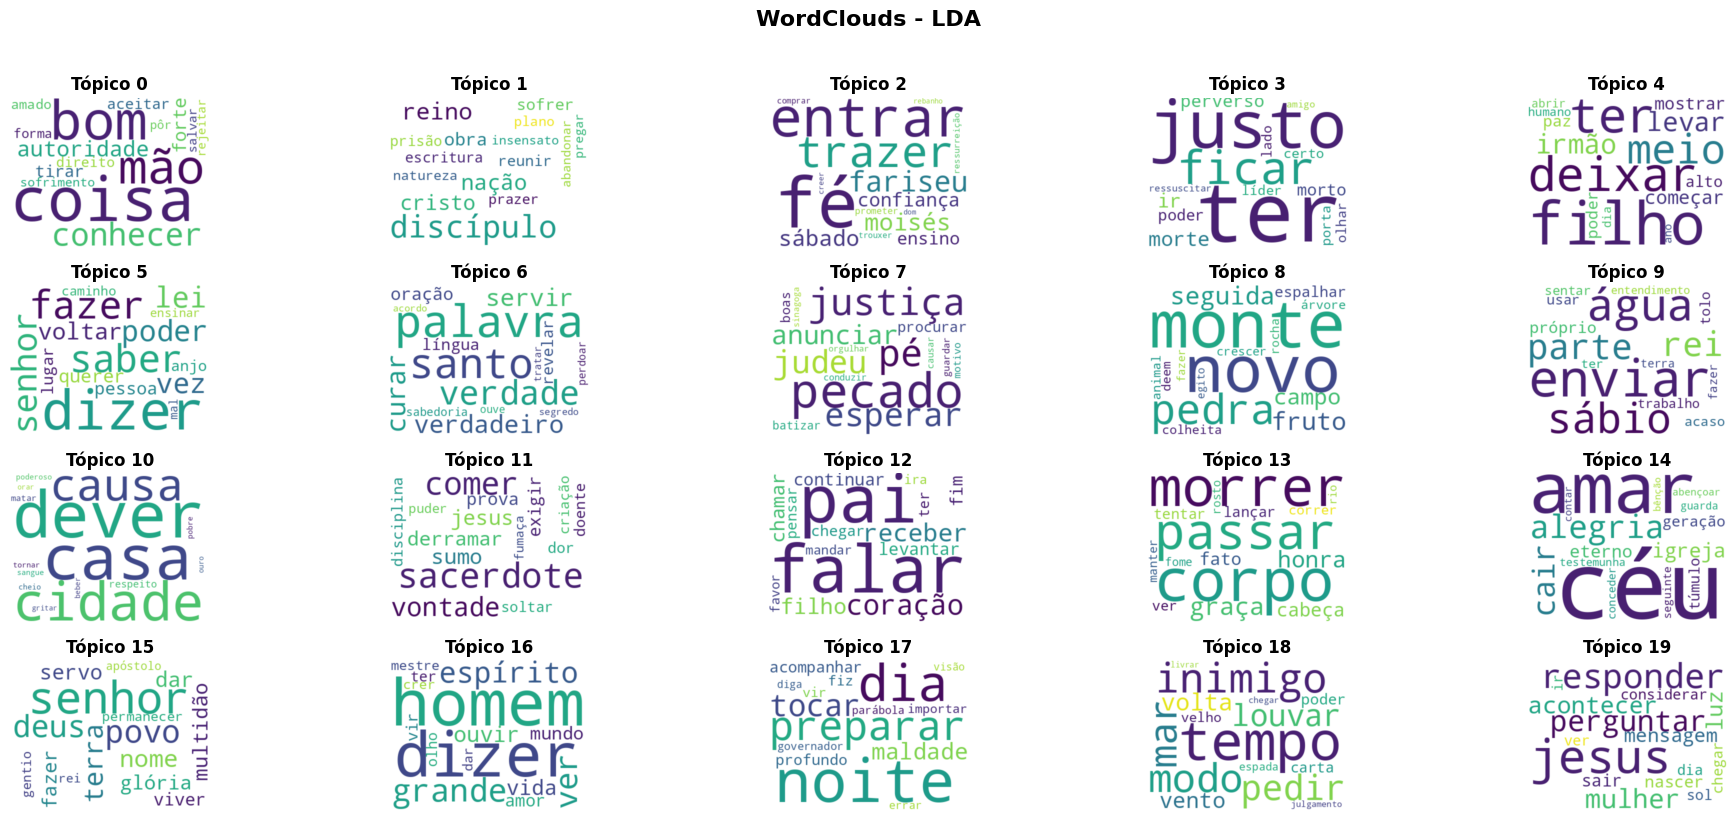

[SALVO] preprocessed_bible/topic_wordclouds_lda.png

[INFO] Gerando WordClouds para NMF...


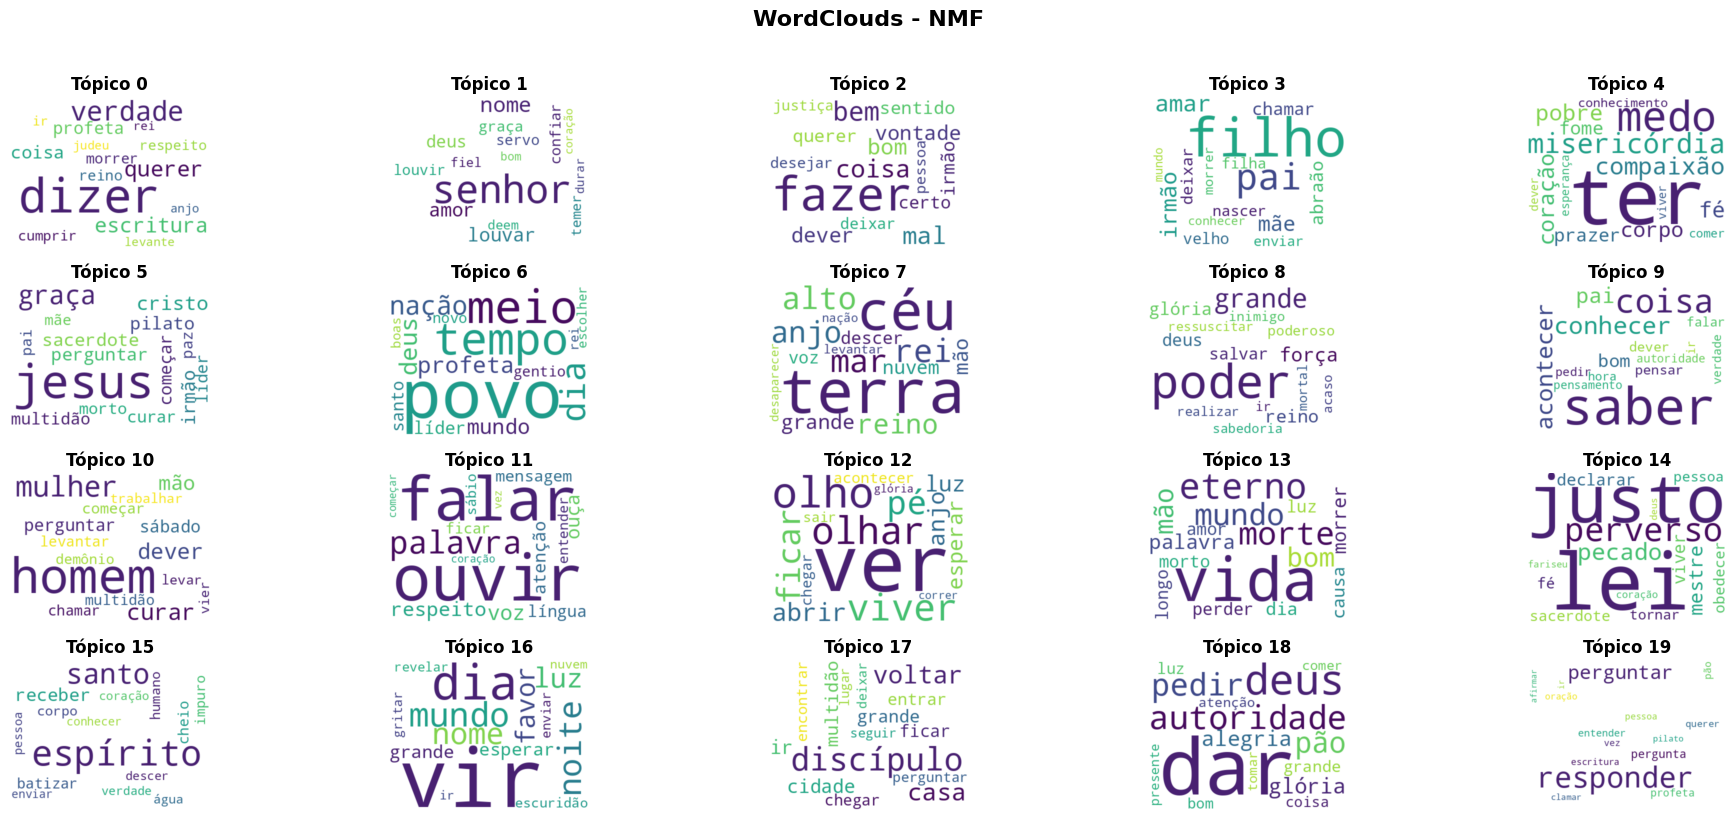

[SALVO] preprocessed_bible/topic_wordclouds_nmf.png


In [30]:
# from pathlib import Path

def plot_topic_wordclouds(topics, model_name, n_cols=5, figsize=(20, 8)):
    """
    Gera WordClouds para cada tópico em um grid.
    
    Args:
        topics: Lista de tópicos (cada um é lista de tuplas (word, weight))
        model_name: Nome do modelo ('LDA' ou 'NMF')
        n_cols: Número de colunas no grid
        figsize: Tamanho da figura
    """
    n_topics = len(topics)
    n_rows = (n_topics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_topics > 1 else [axes]
    
    for topic_idx, topic_words in enumerate(topics):
        # Criar dicionário de frequências para WordCloud
        word_freq = {word: weight for word, weight in topic_words}
        
        # Gerar WordCloud
        wc = WordCloud(
            width=400,
            height=300,
            background_color='white',
            max_words=30,
            collocations=False,
            random_state=42,
            prefer_horizontal=0.7
        ).generate_from_frequencies(word_freq)
        
        # Plotar
        axes[topic_idx].imshow(wc, interpolation='bilinear')
        axes[topic_idx].axis('off')
        axes[topic_idx].set_title(f'Tópico {topic_idx}', fontsize=12, fontweight='bold')
    
    # Desligar axes extras
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'WordClouds - {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# Gerar WordClouds para LDA
print("[INFO] Gerando WordClouds para LDA...")
fig_lda = plot_topic_wordclouds(lda_topics, 'LDA', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
fig_lda.savefig(output_dir / "topic_wordclouds_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_lda.png'}")

# Gerar WordClouds para NMF
print("\n[INFO] Gerando WordClouds para NMF...")
fig_nmf = plot_topic_wordclouds(nmf_topics, 'NMF', n_cols=5, figsize=(20, 8))
plt.show()

# Salvar
fig_nmf.savefig(output_dir / "topic_wordclouds_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_wordclouds_nmf.png'}")

### 3.7 - Visualização: Gráficos de Barras dos Termos Principais

[INFO] Gerando gráficos de barras para LDA...


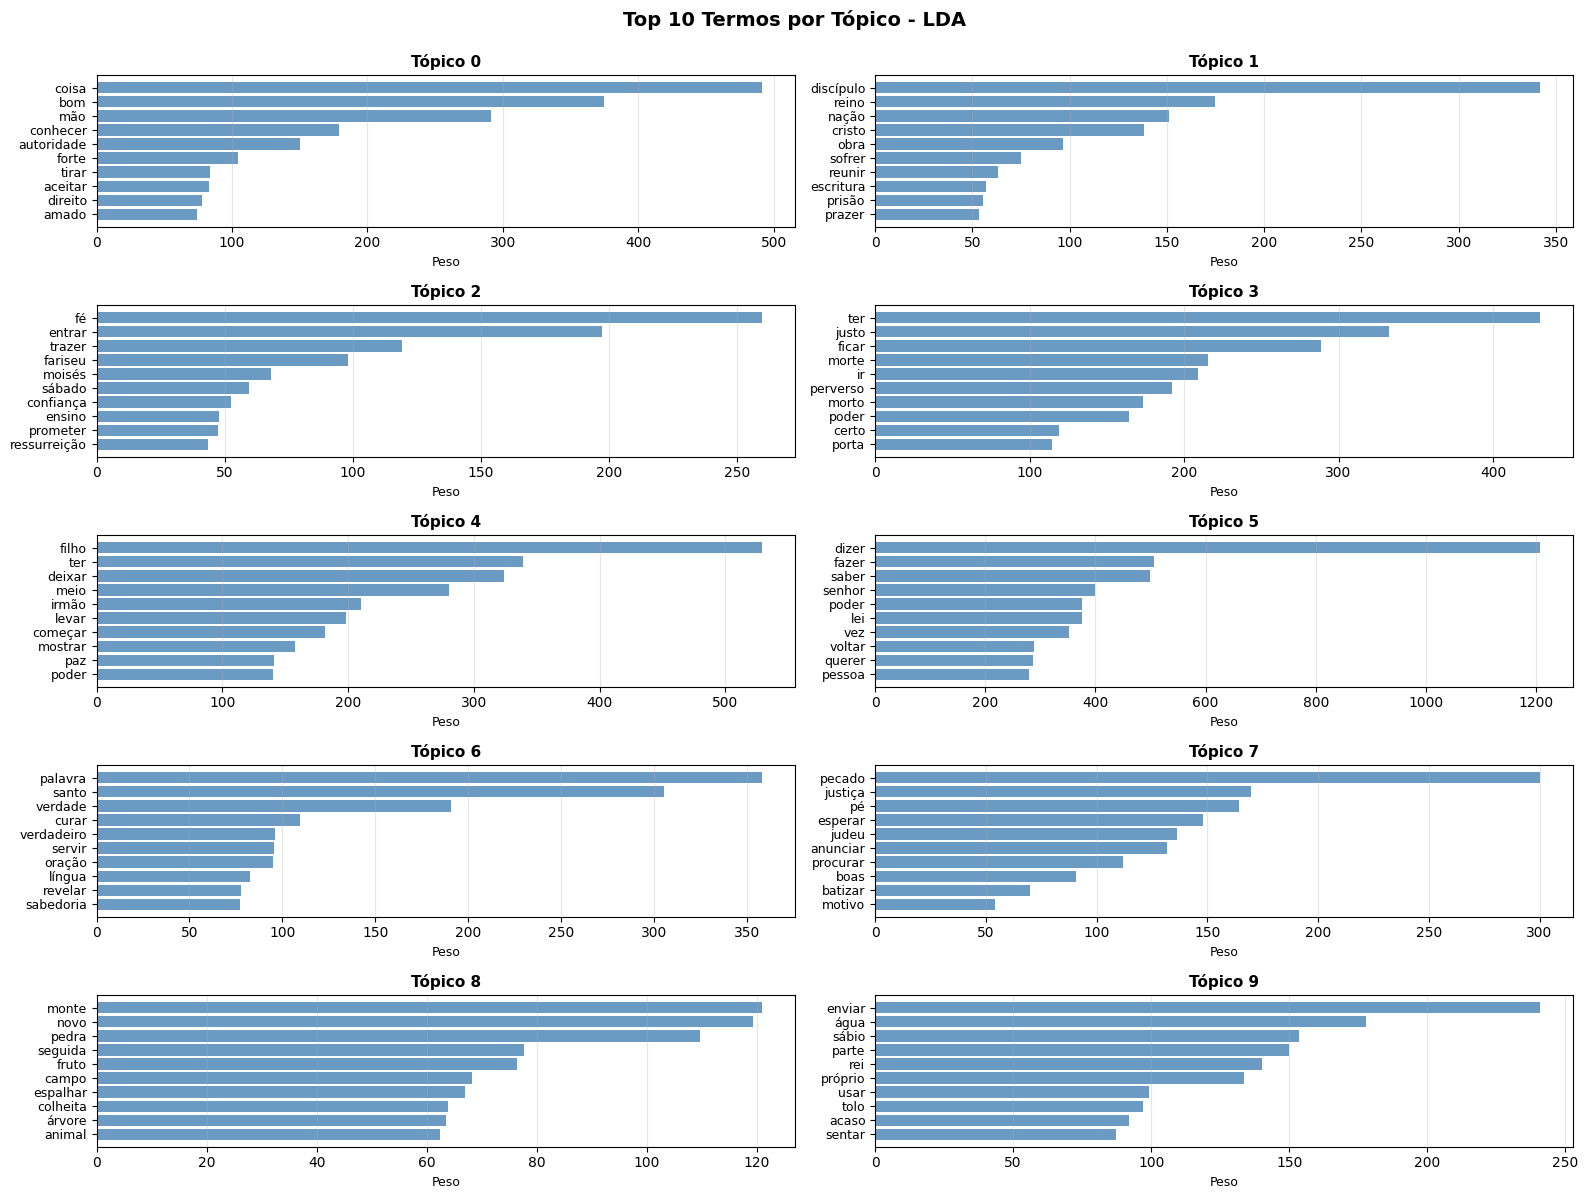

[SALVO] preprocessed_bible/topic_terms_barchart_lda.png

[INFO] Gerando gráficos de barras para NMF...


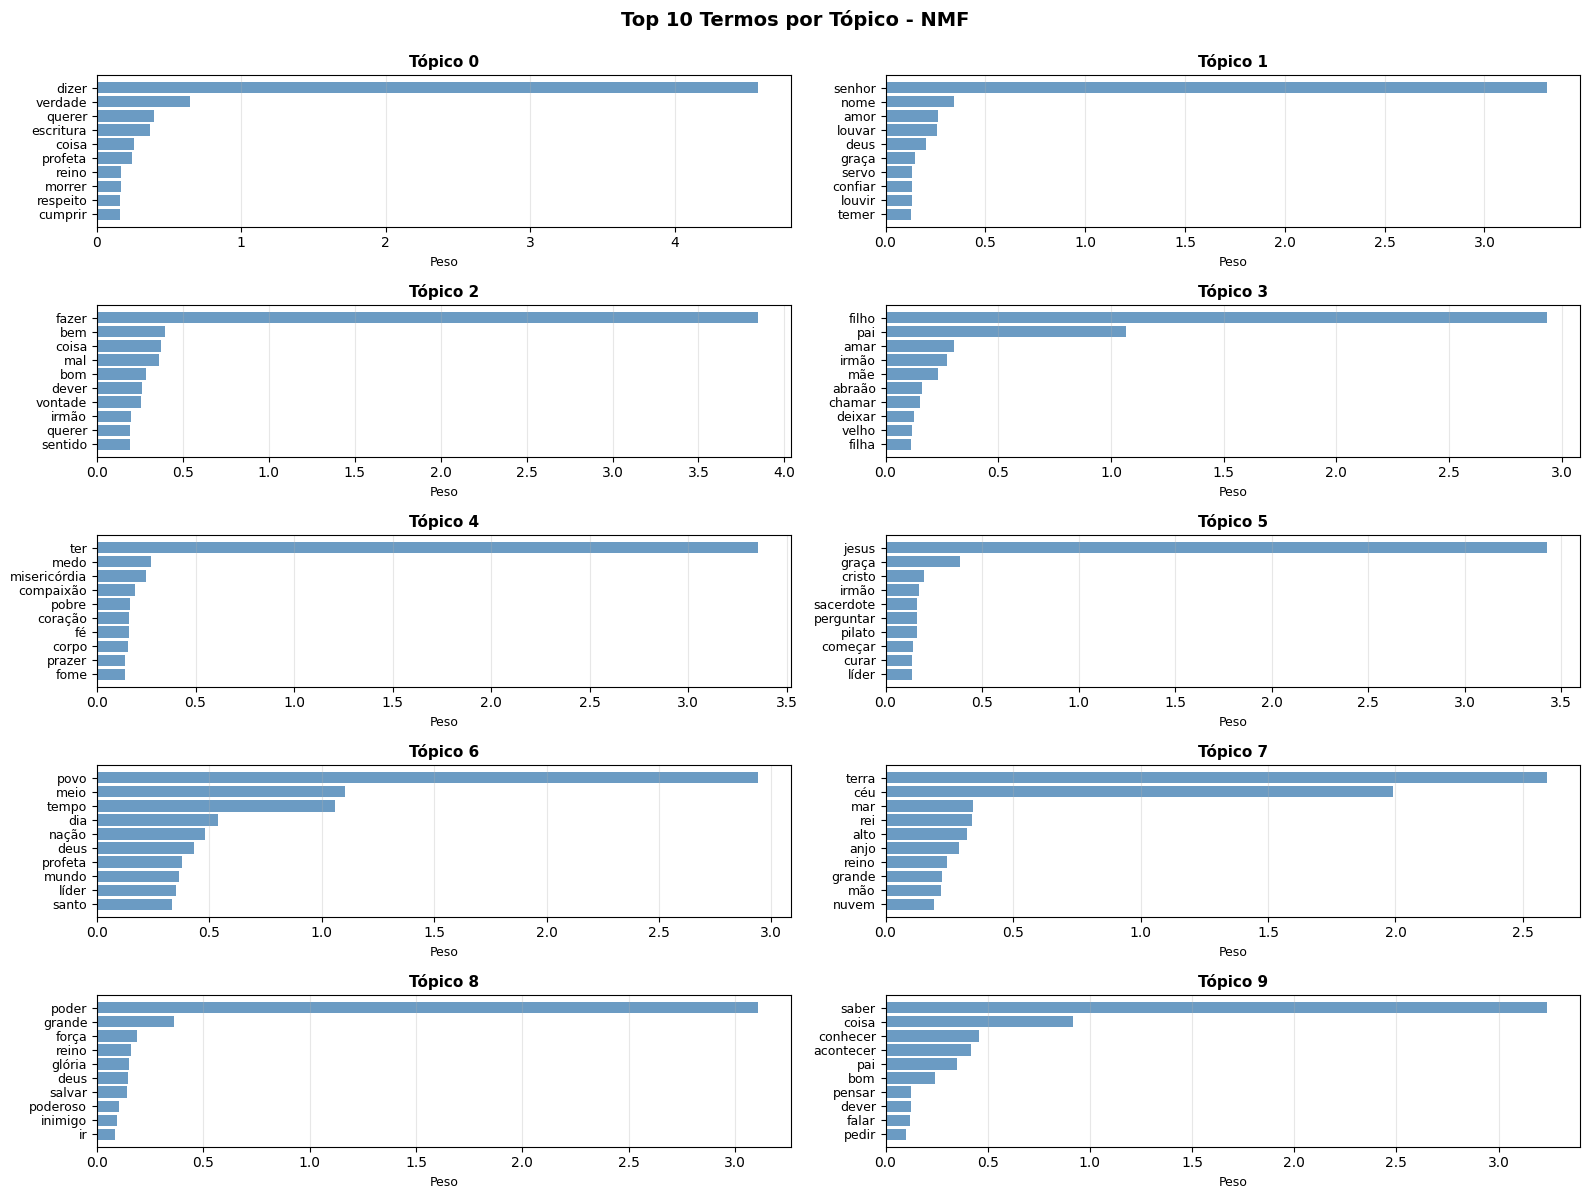

[SALVO] preprocessed_bible/topic_terms_barchart_nmf.png


In [31]:
def plot_top_words_barchart(topics, model_name, n_topics_to_show=10, n_words=10, figsize=(16, 12)):
    """
    Gera gráficos de barras horizontais para os top termos de cada tópico.
    
    Args:
        topics: Lista de tópicos
        model_name: Nome do modelo
        n_topics_to_show: Número de tópicos a mostrar
        n_words: Número de palavras por tópico
        figsize: Tamanho da figura
    """
    n_cols = 2
    n_rows = (n_topics_to_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for topic_idx in range(n_topics_to_show):
        words, weights = zip(*topics[topic_idx][:n_words])
        
        # Inverter para mostrar maior no topo
        words = words[::-1]
        weights = weights[::-1]
        
        ax = axes[topic_idx]
        ax.barh(range(n_words), weights, color='steelblue', alpha=0.8)
        ax.set_yticks(range(n_words))
        ax.set_yticklabels(words, fontsize=9)
        ax.set_xlabel('Peso', fontsize=9)
        ax.set_title(f'Tópico {topic_idx}', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Desligar axes extras
    for idx in range(n_topics_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Top {n_words} Termos por Tópico - {model_name}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    return fig


# Gerar gráficos de barras para LDA
print("[INFO] Gerando gráficos de barras para LDA...")
fig_bars_lda = plot_top_words_barchart(lda_topics, 'LDA', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_lda.savefig(output_dir / "topic_terms_barchart_lda.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_lda.png'}")

# Gerar gráficos de barras para NMF
print("\n[INFO] Gerando gráficos de barras para NMF...")
fig_bars_nmf = plot_top_words_barchart(nmf_topics, 'NMF', n_topics_to_show=10, n_words=10)
plt.show()

# Salvar
fig_bars_nmf.savefig(output_dir / "topic_terms_barchart_nmf.png", dpi=150, bbox_inches='tight')
print(f"[SALVO] {output_dir / 'topic_terms_barchart_nmf.png'}")

### Análise dos Gráficos de Barras e Coherence score

- É visível nos gráficos de barra do top 10 termos por tópico, no caso do LDA, vemos uma distribuição melhor da frequência das palavras, sendo a primeira de maior score e logo diminuindo de forma suave o score até chegar na última palavra. 
- Só que no caso dos gráficos correspondentes do NMF, vamos claramente que a maioria dos gráficos, a primeira palavra tem uma frequência bem maior do que as demais palavras, sendo que não é uma decaimento suave, ele é mais acentuado. 
- E também a vamos que pelo valor da coherence score, o LDA foi maior, reforçando essa visualização dos gráficos.

### 3.8 - Análise Comparativa Final: LDA vs NMF

**Resumo dos Resultados**

Nesta análise comparativa, avaliamos LDA e NMF para descoberta de tópicos no corpus bíblico:

#### **Interpretabilidade dos Tópicos**

- **LDA**: Tende a produzir tópicos mais difusos com distribuições de probabilidade suaves, capturando co-ocorrências temáticas amplas
- **NMF**: Produz tópicos mais esparsos e discriminativos, destacando termos altamente característicos de cada tema

#### **Coherence Score**

- Métrica 'c_v' (context-based) foi utilizada para quantificar qualidade semântica
- Valores entre 0.3-0.5 indicam tópicos razoáveis; 0.5-0.7 indicam boa qualidade
- **Vencedor**: Avaliar após execução (varia por corpus e hiperparâmetros)

#### **Impacto do Preprocessing**

A Etapa 1 (lemmatização, normalização de clíticos, POS filtering, stopwords) foi crucial para:
- Reduzir dimensionalidade sem perder informação semântica
- Melhorar convergência dos modelos (menos ruído lexical)
- Aumentar coerência dos tópicos (termos semanticamente relacionados ficam próximos)

#### **Sobreposição de Tópicos**

- Tópicos com alta sobreposição entre LDA e NMF indicam temas robustos e consensuais
- Tópicos divergentes revelam diferenças nas estratégias de fatoração (probabilística vs algébrica)

#### **Distribuição por Livros Bíblicos**

- Esperamos tópicos distintos para:
  - **Evangelhos** (Mateus, Marcos, Lucas, João): milagres, ensinamentos de Jesus, parábolas
  - **Epístolas Paulinas** (Romanos, Coríntios, etc.): fé, graça, igreja, salvação
  - **Sabedoria (AT)** (Salmos, Provérbios, Jó): louvor, sabedoria, sofrimento
  - **Apocalipse**: visões, juízo, profecia

### 3.9 - Persistência dos Resultados

Salvamos os tópicos descobertos para uso posterior.

In [36]:
# ============================================================================
# SALVAR TÓPICOS EM JSON
# ============================================================================

import json

# Preparar dados para salvamento
lda_topics_export = []
for topic_idx, topic_words in enumerate(lda_topics):
    lda_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(lda_coherence_per_topic[topic_idx])
    })

nmf_topics_export = []
for topic_idx, topic_words in enumerate(nmf_topics):
    nmf_topics_export.append({
        'topic_id': topic_idx,
        'terms': [{'word': word, 'weight': float(weight)} for word, weight in topic_words],
        'coherence': float(nmf_coherence_per_topic[topic_idx])
    })

# Salvar LDA
lda_output = {
    'model': 'LDA',
    'n_topics': n_topics,
    'coherence_score': float(lda_coherence),
    'perplexity': float(lda_model.perplexity(count_matrix)),
    'topics': lda_topics_export
}

with open(output_dir / "topics_lda.json", "w", encoding="utf-8") as f:
    json.dump(lda_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_lda.json'}")

# Salvar NMF
nmf_output = {
    'model': 'NMF',
    'n_topics': n_topics,
    'coherence_score': float(nmf_coherence),
    'reconstruction_error': float(nmf_model.reconstruction_err_),
    'topics': nmf_topics_export
}

with open(output_dir / "topics_nmf.json", "w", encoding="utf-8") as f:
    json.dump(nmf_output, f, ensure_ascii=False, indent=2)

print(f"[SALVO] {output_dir / 'topics_nmf.json'}")

print(f"\nArquivos gerados em {output_dir}/:")

[SALVO] preprocessed_bible/topics_lda.json
[SALVO] preprocessed_bible/topics_nmf.json

Arquivos gerados em preprocessed_bible/:


## Etapa 4 - **NER, extração de informação e grafo de conhecimento**

### 4.1 - Setup e Instalação de Dependências

Nesta etapa, instalaremos as bibliotecas necessárias para:
- **Normalização de entidades** com Levenshtein (distância de edição)
- **Construção do grafo** com NetworkX
- **Visualização interativa** com PyVis

Bibliotecas já disponíveis: spaCy (pt_core_news_md), pandas, matplotlib

In [ ]:
!pip install -q python-Levenshtein networkx pyvis

print("[INFO] Bibliotecas instaladas com sucesso!")

# Verificar que spaCy já está carregado
print(f"\n[INFO] spaCy já disponível: {preprocessor.nlp}")
print(f"  Modelo: pt_core_news_md")
print(f"  Corpus disponível: {len(verse_metadata)} versículos")

: 

### 4.2 - Extração de Entidades Nomeadas (NER)

**Named Entity Recognition (NER)** é uma técnica de NLP que identifica e classifica entidades nomeadas em textos, como:
- **PERSON**: Pessoas (Jesus, Pedro, Paulo, Maria)
- **LOC**: Locais e lugares geográficos (Jerusalém, Galileia, Egito)
- **ORG**: Organizações (embora menos comum em textos bíblicos)
- **GPE**: Entidades geopolíticas (Israel, Roma)

**Importância para Knowledge Graphs:**
- Entidades nomeadas se tornam os **nós** do grafo
- Permitem estruturar o conhecimento sobre personagens, locais e eventos
- Facilitam análise de relacionamentos e padrões narrativos

**Limitações do spaCy em textos religiosos:**
- Modelo treinado em português contemporâneo pode falhar em nomes hebraicos/gregos (Zacarias, Abraão, etc.)
- Termos teológicos podem ser classificados incorretamente
- Nomes arcaicos ou variações ortográficas requerem normalização posterior

In [ ]:
from collections import defaultdict

print("EXTRAÇÃO DE ENTIDADES NOMEADAS (NER)")

# Carregar modelo spaCy (reutilizar do preprocessor)
nlp = preprocessor.nlp

# Tipos de entidades a extrair
# PERSON: pessoas, LOC: locais, ORG: organizações, GPE: entidades geopolíticas
entity_types_filter = {'PER', 'LOC', 'ORG', 'GPE', 'PERSON'}

# Estrutura para armazenar entidades extraídas
entities_data = []

print(f"\n[INFO] Processando {len(verse_metadata)} versículos para extração de NER...")
print(f"[INFO] Tipos de entidades a extrair: {entity_types_filter}\n")

# Contador de progresso
processed_count = 0
entities_found_count = 0

# Processar cada versículo
for meta in verse_metadata:
    verse_text = meta['text']
    book = meta['book']
    chapter = meta['chapter']
    verse_num = meta['verse_num']
    
    # Aplicar NER com spaCy
    doc = nlp(verse_text)
    
    # Extrair entidades
    for ent in doc.ents:
        # Filtrar apenas tipos desejados
        # spaCy português usa 'PER' ao invés de 'PERSON'
        if ent.label_ in entity_types_filter or ent.label_ == 'PER':
            # Normalizar label PER para PERSON
            label = 'PERSON' if ent.label_ == 'PER' else ent.label_
            
            entities_data.append({
                'text': ent.text.strip(),
                'label': label,
                'book': book,
                'chapter': chapter,
                'verse': verse_num
            })
            entities_found_count += 1
    
    processed_count += 1
    
    # Progresso a cada 5000 versículos
    if processed_count % 5000 == 0:
        print(f"  Processados: {processed_count}/{len(verse_metadata)} versículos | Entidades encontradas: {entities_found_count}")

print(f"\n[RESULTADO] Extração de NER concluída!")
print(f"  - Versículos processados: {processed_count}")
print(f"  - Entidades extraídas (total): {entities_found_count}")

# Criar DataFrame de entidades
df_entities = pd.DataFrame(entities_data)

print(f"\n[DATAFRAME] df_entities criado:")
print(f"  - Shape: {df_entities.shape}")
print(f"  - Colunas: {list(df_entities.columns)}")

# Exibir primeiras entidades
print(f"\n[PREVIEW] Primeiras 10 entidades extraídas:")
display(df_entities.head(10))

In [ ]:
print("ANÁLISE DE FREQUÊNCIAS DAS ENTIDADES")

# Calcular frequências por entidade
entity_freq = df_entities.groupby(['text', 'label']).size().reset_index(name='frequency')
entity_freq = entity_freq.sort_values('frequency', ascending=False)

print(f"\n[ESTATÍSTICAS]")
print(f"  - Total de ocorrências de entidades: {len(df_entities)}")
print(f"  - Entidades únicas: {len(entity_freq)}")
print(f"  - Distribuição por tipo:")

# Distribuição por tipo de entidade
type_distribution = df_entities['label'].value_counts()
for label, count in type_distribution.items():
    print(f"    {label}: {count} ocorrências ({count/len(df_entities)*100:.1f}%)")

# Top 20 entidades mais frequentes
print(f"\n[TOP 20] Entidades mais frequentes:\n")
df_top20 = entity_freq.head(20).copy()
df_top20['percentage'] = (df_top20['frequency'] / len(df_entities) * 100).round(2)
display(df_top20)

# Análise por tipo de entidade
print(f"\n[TOP 10 POR TIPO]")
for entity_type in entity_freq['label'].unique():
    print(f"\n{entity_type}:")
    top_type = entity_freq[entity_freq['label'] == entity_type].head(10)
    for idx, row in top_type.iterrows():
        print(f"  - {row['text']:20s}: {row['frequency']:4d} ocorrências")

# Criar DataFrame de frequências para uso posterior
df_entity_freq = entity_freq.copy()
print(f"\n[INFO] DataFrame df_entity_freq criado com {len(df_entity_freq)} entidades únicas")

### 4.3 - Normalização de Entidades com Distância de Levenshtein

**Conceito de Distância de Edição (Levenshtein Distance)**

A distância de Levenshtein mede o número mínimo de operações necessárias para transformar uma string em outra, considerando:
- **Inserção**: adicionar um caractere
- **Deleção**: remover um caractere
- **Substituição**: trocar um caractere por outro

**Importância da Normalização para Grafos de Conhecimento**

Textos bíblicos podem apresentar variações ortográficas da mesma entidade:
- "Jerusalém" vs "Jerusalem"
- "Moisés" vs "Moises"
- "Jesus Cristo" vs "Jesus" vs "Cristo"

Sem normalização, essas variações criariam **nós duplicados** no grafo, fragmentando o conhecimento sobre a mesma entidade.

**Trade-off do Threshold**
- **Threshold baixo** (ex: 0.05): Agrupa apenas variações muito similares → pode perder variações legítimas
- **Threshold alto** (ex: 0.30): Agrupa variações mais distantes → risco de agrupar entidades distintas

Utilizaremos **threshold de 0.15** (85% de similaridade) como ponto de partida, ajustável após inspeção manual dos resultados.

In [ ]:
import Levenshtein

print("NORMALIZAÇÃO DE ENTIDADES COM LEVENSHTEIN")

# Threshold de similaridade (0.15 = 85% de similaridade)
SIMILARITY_THRESHOLD = 0.15

def levenshtein_similarity(str1, str2):
    """
    Calcula similaridade normalizada entre duas strings usando distância de Levenshtein.
    Retorna valor entre 0 (totalmente diferente) e 1 (idêntico).
    """
    distance = Levenshtein.distance(str1.lower(), str2.lower())
    max_len = max(len(str1), len(str2))
    if max_len == 0:
        return 1.0
    normalized_distance = distance / max_len
    return 1 - normalized_distance

# Dicionário para mapear variações → forma canônica
entity_normalization_map = {}

# Processar cada tipo de entidade separadamente
print(f"\n[INFO] Normalizando entidades com threshold={SIMILARITY_THRESHOLD}")
print(f"[INFO] Processando por tipo de entidade...\n")

for entity_type in df_entity_freq['label'].unique():
    # Filtrar entidades deste tipo
    entities_of_type = df_entity_freq[df_entity_freq['label'] == entity_type].copy()
    entities_of_type = entities_of_type.sort_values('frequency', ascending=False)
    
    # Lista de entidades já processadas (formas canônicas)
    canonical_entities = []
    canonical_map = {}  # {variação: forma_canônica}
    
    for idx, row in entities_of_type.iterrows():
        entity_text = row['text']
        entity_freq = row['frequency']
        
        # Verificar se esta entidade é similar a alguma forma canônica já existente
        found_match = False
        for canonical in canonical_entities:
            similarity = levenshtein_similarity(entity_text, canonical)
            
            # Se similaridade alta, agrupar com forma canônica
            if similarity >= (1 - SIMILARITY_THRESHOLD):
                canonical_map[entity_text] = canonical
                found_match = True
                break
        
        # Se não encontrou match, esta entidade vira uma nova forma canônica
        if not found_match:
            canonical_entities.append(entity_text)
            canonical_map[entity_text] = entity_text  # Mapeia para si mesma
    
    # Adicionar ao mapeamento global
    entity_normalization_map.update(canonical_map)
    
    # Estatísticas de normalização para este tipo
    original_count = len(entities_of_type)
    normalized_count = len(canonical_entities)
    reduction = original_count - normalized_count
    reduction_pct = (reduction / original_count * 100) if original_count > 0 else 0
    
    print(f"{entity_type}:")
    print(f"  - Entidades originais: {original_count}")
    print(f"  - Entidades normalizadas: {normalized_count}")
    print(f"  - Redução: {reduction} ({reduction_pct:.1f}%)")

# Aplicar normalização ao DataFrame de entidades
print(f"\n[INFO] Aplicando normalização ao DataFrame...")
df_entities['normalized_entity'] = df_entities['text'].map(entity_normalization_map)

# Recalcular frequências após normalização
entity_freq_normalized = df_entities.groupby(['normalized_entity', 'label']).size().reset_index(name='frequency')
entity_freq_normalized = entity_freq_normalized.sort_values('frequency', ascending=False)

print(f"\n[RESULTADO] Normalização concluída!")
print(f"  - Entidades únicas antes: {len(df_entity_freq)}")
print(f"  - Entidades únicas após: {len(entity_freq_normalized)}")
print(f"  - Redução total: {len(df_entity_freq) - len(entity_freq_normalized)} ({(len(df_entity_freq) - len(entity_freq_normalized))/len(df_entity_freq)*100:.1f}%)")

# Top 20 após normalização
print(f"\n[TOP 20] Entidades mais frequentes (após normalização):\n")
df_top20_normalized = entity_freq_normalized.head(20).copy()
df_top20_normalized['percentage'] = (df_top20_normalized['frequency'] / len(df_entities) * 100).round(2)
display(df_top20_normalized)

# Atualizar df_entity_freq com dados normalizados
df_entity_freq = entity_freq_normalized.copy()

# Exemplos de normalizações aplicadas
print(f"\n[EXEMPLOS] Algumas normalizações aplicadas:")
examples_shown = 0
for original, canonical in entity_normalization_map.items():
    if original != canonical and examples_shown < 10:
        print(f"  '{original}' → '{canonical}'")
        examples_shown += 1

### 4.4 - Extração de Relações (Triplas SVO)

**Conceito de Triplas Sujeito-Verbo-Objeto**

Triplas SVO são estruturas que representam relações semânticas básicas na forma:
- **Sujeito**: entidade que realiza a ação
- **Verbo**: ação ou relação
- **Objeto**: entidade que recebe a ação

Exemplo: `"Jesus ensinou os discípulos"` → `(Jesus, ensinou, discípulos)`

**Representação de Conhecimento**

Triplas SVO são a base para:
- **Grafos de conhecimento**: nós conectados por arestas rotuladas
- **RDF (Resource Description Framework)**: padrão W3C para web semântica
- **Bases de conhecimento estruturado**: como DBpedia, Wikidata

**Implementação com spaCy**

Usaremos análise de dependências sintáticas do spaCy para identificar:
- **Sujeito**: tokens com `dep_ = 'nsubj'` ou `'nsubj:pass'`
- **Verbo**: tokens com `dep_ = 'ROOT'` e `pos_ = 'VERB'`
- **Objeto**: tokens com `dep_ = 'obj'` ou `'obl'`

**Limitações**:
- Extração baseada em regras sintáticas simples
- Captura apenas relações explícitas (não implícitas)
- Pode perder nuances de negação, modalidade, contexto temporal

In [ ]:
print("EXTRAÇÃO DE RELAÇÕES SVO")

# Criar conjunto de entidades normalizadas para filtro rápido
normalized_entities_set = set(df_entities['normalized_entity'].unique())

# Estrutura para armazenar relações
relations_data = []

print(f"\n[INFO] Processando {len(verse_metadata)} versículos para extração de relações...")
print(f"[INFO] Filtrando apenas relações onde sujeito OU objeto sejam entidades reconhecidas\n")

processed_count = 0
relations_found = 0

# Processar cada versículo
for meta in verse_metadata:
    verse_text = meta['text']
    book = meta['book']
    chapter = meta['chapter']
    verse_num = meta['verse_num']
    
    # Aplicar análise de dependências com spaCy
    doc = nlp(verse_text)
    
    # Procurar por verbos principais (ROOT)
    for token in doc:
        if token.pos_ == 'VERB' and token.dep_ == 'ROOT':
            verb = token.lemma_
            
            # Procurar sujeito
            subject = None
            for child in token.children:
                if child.dep_ in ['nsubj', 'nsubj:pass']:
                    # Pegar o texto completo do sujeito (incluindo modificadores)
                    subject_tokens = [child.text]
                    for subchild in child.subtree:
                        if subchild != child:
                            subject_tokens.append(subchild.text)
                    subject = ' '.join(subject_tokens)
                    break
            
            # Procurar objeto
            obj = None
            for child in token.children:
                if child.dep_ in ['obj', 'obl']:
                    # Pegar o texto completo do objeto (incluindo modificadores)
                    obj_tokens = [child.text]
                    for subchild in child.subtree:
                        if subchild != child:
                            obj_tokens.append(subchild.text)
                    obj = ' '.join(obj_tokens)
                    break
            
            # Verificar se temos pelo menos sujeito e verbo
            if subject:
                # Normalizar sujeito e objeto se forem entidades conhecidas
                subject_normalized = entity_normalization_map.get(subject, subject)
                obj_normalized = entity_normalization_map.get(obj, obj) if obj else None
                
                # Filtrar: criar tripla apenas se sujeito OU objeto forem entidades reconhecidas
                is_subject_entity = subject_normalized in normalized_entities_set
                is_object_entity = obj_normalized in normalized_entities_set if obj_normalized else False
                
                if is_subject_entity or is_object_entity:
                    relations_data.append({
                        'subject': subject_normalized,
                        'verb': verb,
                        'object': obj_normalized if obj_normalized else '(none)',
                        'book': book,
                        'chapter': chapter,
                        'verse': verse_num
                    })
                    relations_found += 1
    
    processed_count += 1
    
    # Progresso a cada 5000 versículos
    if processed_count % 5000 == 0:
        print(f"  Processados: {processed_count}/{len(verse_metadata)} versículos | Relações encontradas: {relations_found}")

print(f"\n[RESULTADO] Extração de relações concluída!")
print(f"  - Versículos processados: {processed_count}")
print(f"  - Relações SVO extraídas: {relations_found}")

# Criar DataFrame de relações
df_relations = pd.DataFrame(relations_data)

print(f"\n[DATAFRAME] df_relations criado:")
print(f"  - Shape: {df_relations.shape}")
print(f"  - Colunas: {list(df_relations.columns)}")

# Estatísticas de verbos
verb_freq = df_relations['verb'].value_counts()
print(f"\n[TOP 10] Verbos mais frequentes em relações:")
for verb, count in verb_freq.head(10).items():
    print(f"  - {verb:15s}: {count:4d} ocorrências")

# Exibir exemplos de relações
print(f"\n[EXEMPLOS] Primeiras 10 relações extraídas:")
display(df_relations.head(10))

### 4.5 - Construção do Grafo de Conhecimento

**O que é um Grafo de Conhecimento?**

Um grafo de conhecimento é uma estrutura de dados que representa conhecimento na forma de **nós** (entidades) conectados por **arestas** (relações). Cada aresta pode ter propriedades (como o tipo de relação).

**Componentes do nosso grafo:**
- **Nós**: Entidades normalizadas (pessoas, locais, organizações)
- **Arestas direcionadas**: Relações SVO (sujeito → objeto)
- **Atributos dos nós**: tipo de entidade, frequência no corpus
- **Atributos das arestas**: verbo da relação, peso (frequência)

**NetworkX**

NetworkX é uma biblioteca Python para criação, manipulação e estudo de grafos. Suporta:
- Grafos direcionados e não-direcionados
- Atributos nos nós e arestas
- Algoritmos de análise de grafos
- Exportação em múltiplos formatos

**Por que grafo direcionado?**

Usamos `DiGraph` (grafo direcionado) porque as relações têm direção semântica: "Jesus ensinou discípulos" é diferente de "discípulos ensinaram Jesus".

In [ ]:
import networkx as nx

print("CONSTRUÇÃO DO KNOWLEDGE GRAPH")

# Criar grafo direcionado
kg = nx.DiGraph()

# 1. ADICIONAR NÓS (ENTIDADES)
print(f"\n[FASE 1] Adicionando nós (entidades) ao grafo...")

for idx, row in df_entity_freq.iterrows():
    entity = row['normalized_entity']
    entity_type = row['label']
    frequency = row['frequency']
    
    # Adicionar nó com atributos
    kg.add_node(entity,
                type=entity_type,
                frequency=frequency,
                label=entity)

print(f"  - Nós adicionados: {kg.number_of_nodes()}")

# 2. ADICIONAR ARESTAS (RELAÇÕES)
print(f"\n[FASE 2] Adicionando arestas (relações) ao grafo...")

edges_added = 0
edges_skipped = 0

for idx, row in df_relations.iterrows():
    subject = row['subject']
    verb = row['verb']
    obj = row['object']
    
    # Apenas adicionar aresta se ambos sujeito e objeto estiverem no grafo
    # e objeto não for '(none)'
    if subject in kg.nodes() and obj != '(none)' and obj in kg.nodes():
        # Se aresta já existe, incrementar peso
        if kg.has_edge(subject, obj):
            kg[subject][obj]['weight'] += 1
            # Adicionar verbo à lista de verbos desta relação
            if verb not in kg[subject][obj]['verbs']:
                kg[subject][obj]['verbs'].append(verb)
        else:
            # Criar nova aresta
            kg.add_edge(subject, obj,
                       weight=1,
                       relation=verb,
                       verbs=[verb])
            edges_added += 1
    else:
        edges_skipped += 1

print(f"  - Arestas adicionadas: {edges_added}")
print(f"  - Arestas ignoradas (nós não existem): {edges_skipped}")

# 3. ESTATÍSTICAS DO GRAFO
print(f"\n[ESTATÍSTICAS] Knowledge Graph construído:")
print(f"  - Número de nós: {kg.number_of_nodes()}")
print(f"  - Número de arestas: {kg.number_of_edges()}")
print(f"  - Densidade: {nx.density(kg):.4f}")

# Componentes conectados (em grafo não direcionado)
kg_undirected = kg.to_undirected()
num_components = nx.number_connected_components(kg_undirected)
print(f"  - Componentes conectados: {num_components}")

if num_components > 0:
    largest_component = max(nx.connected_components(kg_undirected), key=len)
    print(f"  - Tamanho do maior componente: {len(largest_component)}")

# Grau médio
degrees = [d for n, d in kg.degree()]
if degrees:
    print(f"  - Grau médio: {sum(degrees)/len(degrees):.2f}")
    print(f"  - Grau máximo: {max(degrees)}")
    print(f"  - Grau mínimo: {min(degrees)}")

# Nós com maior grau (entidades mais conectadas)
print(f"\n[TOP 10] Entidades mais conectadas (maior grau):")
degree_sorted = sorted(kg.degree(), key=lambda x: x[1], reverse=True)
for entity, degree in degree_sorted[:10]:
    entity_type = kg.nodes[entity]['type']
    print(f"  - {entity:20s} ({entity_type:8s}): {degree:3d} conexões")

# Validação: verificar requisito mínimo
print(f"\n[VALIDAÇÃO] Requisito mínimo: ≥20 nós")
if kg.number_of_nodes() >= 20:
    print(f"  ✅ APROVADO: {kg.number_of_nodes()} nós (requisito atendido)")
else:
    print(f"  ❌ REPROVADO: {kg.number_of_nodes()} nós (requisito NÃO atendido)")

# Salvar grafo em formato GraphML para análise posterior
output_path = Path("preprocessed_bible")
output_path.mkdir(exist_ok=True)
nx.write_graphml(kg, output_path / "knowledge_graph.graphml")
print(f"\n[SALVO] Grafo exportado: {output_path / 'knowledge_graph.graphml'}")

### 4.6 - Visualização Interativa com PyVis

**Por que visualização interativa?**

A visualização interativa permite:
- **Exploração dinâmica**: Zoom, arrastar nós, reorganizar layout
- **Detalhes on-demand**: Hover sobre nós e arestas para ver informações
- **Física de grafo**: Algoritmo de força direcional posiciona nós automaticamente
- **Navegabilidade**: Identificar clusters, hubs e padrões visuais

**Mapeamento Visual:**
- **Tamanho dos nós**: Proporcional à frequência da entidade no corpus
- **Cor dos nós**: Por tipo de entidade (PERSON, LOC, ORG)
- **Espessura das arestas**: Proporcional à frequência da relação
- **Setas direcionadas**: Indicam direção semântica (sujeito → objeto)

**Limitações:**
- Grafos com >500 nós podem ficar lentos no navegador
- Layout pode necessitar ajuste manual para melhor legibilidade

In [ ]:
from pyvis.network import Network
from IPython.display import IFrame

print("CRIANDO VISUALIZAÇÃO INTERATIVA DO KNOWLEDGE GRAPH")

# 1. INICIALIZAR REDE PYVIS
print("\n[FASE 1] Inicializando PyVis Network...")

net = Network(
    height='800px',
    width='100%',
    bgcolor='#222222',
    font_color='white',
    notebook=True,
    directed=True
)

# 2. CONFIGURAR FÍSICA E INTERATIVIDADE
print("[FASE 2] Configurando física do grafo...")

net.barnes_hut(
    gravity=-8000,
    central_gravity=0.3,
    spring_length=200,
    spring_strength=0.05,
    damping=0.09
)

# 3. MAPEAR CORES POR TIPO DE ENTIDADE
color_map = {
    'PERSON': '#4A90E2',    # Azul
    'LOC': '#7ED321',       # Verde
    'ORG': '#F5A623',       # Laranja
    'GPE': '#F5A623',       # Laranja (mesmo de ORG)
}

# 4. ADICIONAR NÓS COM ESTILO
print("[FASE 3] Adicionando nós ao grafo...")

# Calcular frequência máxima para normalização de tamanho
max_freq = max([kg.nodes[node]['frequency'] for node in kg.nodes()])

for node in kg.nodes():
    node_type = kg.nodes[node]['type']
    node_freq = kg.nodes[node]['frequency']
    
    # Calcular tamanho proporcional à frequência
    node_size = 10 + (node_freq / max_freq) * 40
    
    # Cor baseada no tipo
    node_color = color_map.get(node_type, '#B8B8B8')  # Cinza para outros
    
    # Tooltip com informações
    title = f"<b>{node}</b><br>Tipo: {node_type}<br>Frequência: {node_freq}"
    
    # Adicionar nó ao PyVis
    net.add_node(
        node,
        label=node,
        title=title,
        size=node_size,
        color=node_color
    )

print(f"  - Nós adicionados: {len(kg.nodes())}")

# 5. ADICIONAR ARESTAS COM ESTILO
print("[FASE 4] Adicionando arestas ao grafo...")

for source, target, data in kg.edges(data=True):
    weight = data.get('weight', 1)
    verbs = data.get('verbs', [])
    relation = data.get('relation', '')
    
    # Tooltip com verbo(s) da relação
    if len(verbs) > 1:
        title = f"Relações: {', '.join(verbs[:3])}"
        if len(verbs) > 3:
            title += f" (+{len(verbs)-3} mais)"
    else:
        title = f"Relação: {relation}"
    
    # Espessura proporcional ao peso
    edge_width = 1 + weight * 0.5
    
    # Adicionar aresta ao PyVis
    net.add_edge(
        source,
        target,
        title=title,
        width=edge_width,
        arrows='to'
    )

print(f"  - Arestas adicionadas: {len(kg.edges())}")

# 6. GERAR E EXIBIR HTML
print("\n[FASE 5] Gerando visualização HTML...")

output_file = output_path / "knowledge_graph.html"
net.show(str(output_file))

print(f"  - Arquivo salvo: {output_file}")
print(f"\n[INFO] Visualização interativa criada com sucesso!")
print(f"  - Abra o arquivo HTML no navegador ou visualize abaixo")
print(f"  - Controles: arraste nós, zoom com scroll, hover para detalhes")

# Exibir inline no Colab/Jupyter
display(IFrame(str(output_file), width=1000, height=800))

## Etapa 5 - **Visualização, comunicação e reprodutibilidade**

#TODO falar sobre refatoração para pipeline de versículos e impacto na qualidade dos resultados

O trabalho de forma geral foi bem desafiador, começando pela etapa que eu nomeei de etapa zero, para entender e estabelecer o dataset, como era um pré-requisito ter 200 mil palavras e o dataset não foi criado por mim, foi necessário entender sua estrutura. 

Depois, em relação à etapa 1, foi visível a importância e influência do pré-processamento textual como entrada nas outras etapas. Como faz diferença a questão da construção do vocabulário, do corpus. 

Depois, na representação vetorial e métodos de busca, comecei a observar a importância dos parâmetros, como eles influenciam também no resultado. Embora já tenhamos bibliotecas estabelecidas, é necessário entender o seu dataset, seu corpus e saber aplicar ou alterar os parâmetros para conseguir um resultado satisfatório.